# Global seasonality of Measles

Hi Annette! Marina told me you had discussed the seasonality of measles epidemiology in Germany and internationally. I have worked a bit on some descriptive analysis of measles in Germany and globally, so I also covered that a little bit.

Here I highlight that the seasonality drastically changes depending on the place in the world. In the Northern Hemisphere we see outbreaks predominantly occurring in the first few months of the year, while in the Southern Hemisphere this is mostly around September or so.

There is some literature on this, though not as extensive as one may hope. Jia et al., found that there is some correlation between temperature and measles risk in China, as did Yang and colleagues. Yang found that the risk of measles increased especially drastically at a temperature of 18-20 degrees. They further argued that a the more the temperature is away from this point, the smaller the risk (so both extremes are 'bad for the virus'). This was also found in Nigeria (https://pubs.sciepub.com/ajphr/6/4/4/index.html) People have similarly shown this in the lab (this was already shown in 1964!!).

This little exercise shows some plots for some countries in the world, using this data from the WHO (https://immunizationdata.who.int/global?topic=Provisional-measles-and-rubella-data&location=) (go to: Distribution of measles and rubella cases by country, year, month and final classification).

I cannot vouch for the quality of the data to be honest, as there are quite some gaps and the monthly data does not always add up to the annual data published by the WHO.

Regardless, the data gives a good impression of the seasonality - difference in the world.




Jia 2023
Yang 2014

12. De Jong JG. The survival of measles virus in air, in
relation to the epidemiology of measles. Arch Gesamte
Virusforsch 1965; 16:97-102; PMID:14322937;
http://dx.doi.org/10.1007/BF01253797
13. De Jong JG, Winkler KC. Survival of measles virus
in air. Nature 1964; 201:1054-5; PMID:

11. Opio CO. Diagnosis of the relationship between
weather variables and occurrences of measles in Soroti
and Serere districts. 2011.

https://pubs.sciepub.com/ajphr/6/4/4/index.html


In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *


who_international_casedata = pd.read_csv(os.path.join(data_env,'processed/international/epidemiology/casedata/who_mv_monthly.csv'))


In [ ]:
countries_harmfile = pd.read_csv(os.path.join(data_env,'processed/international/geospatial/harmonization/world_harmonization.tsv'), sep="\t")

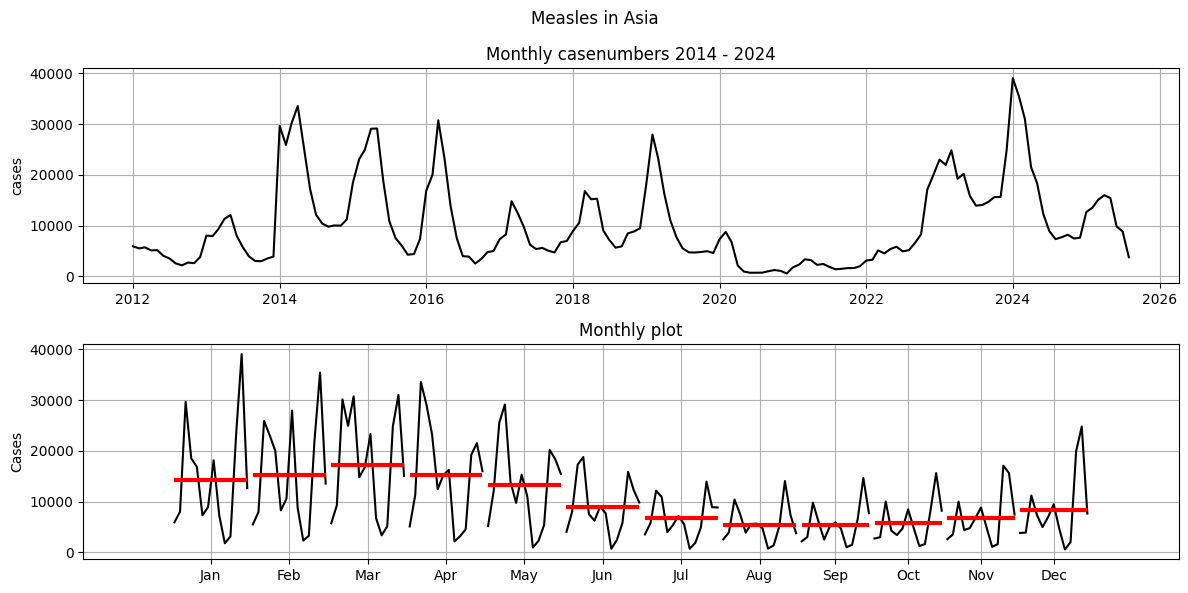

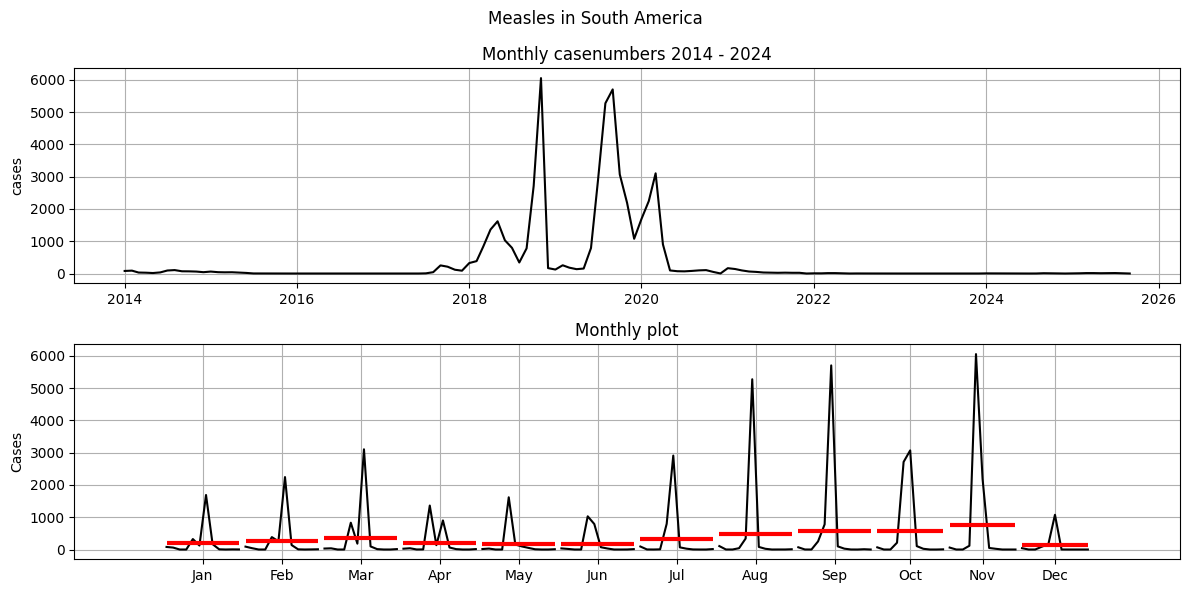

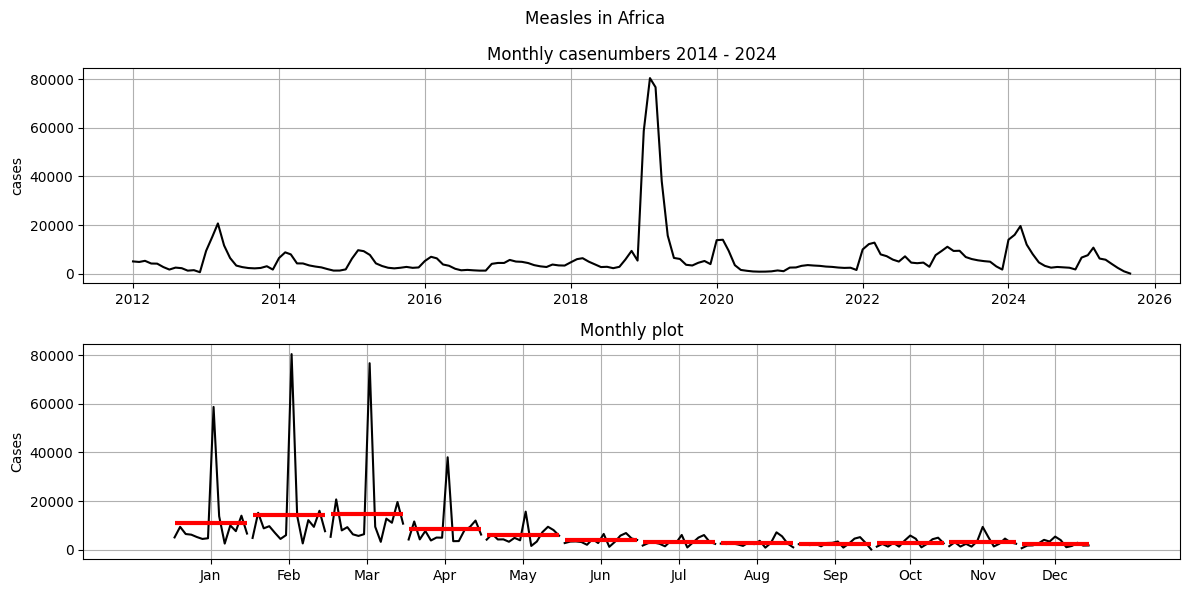

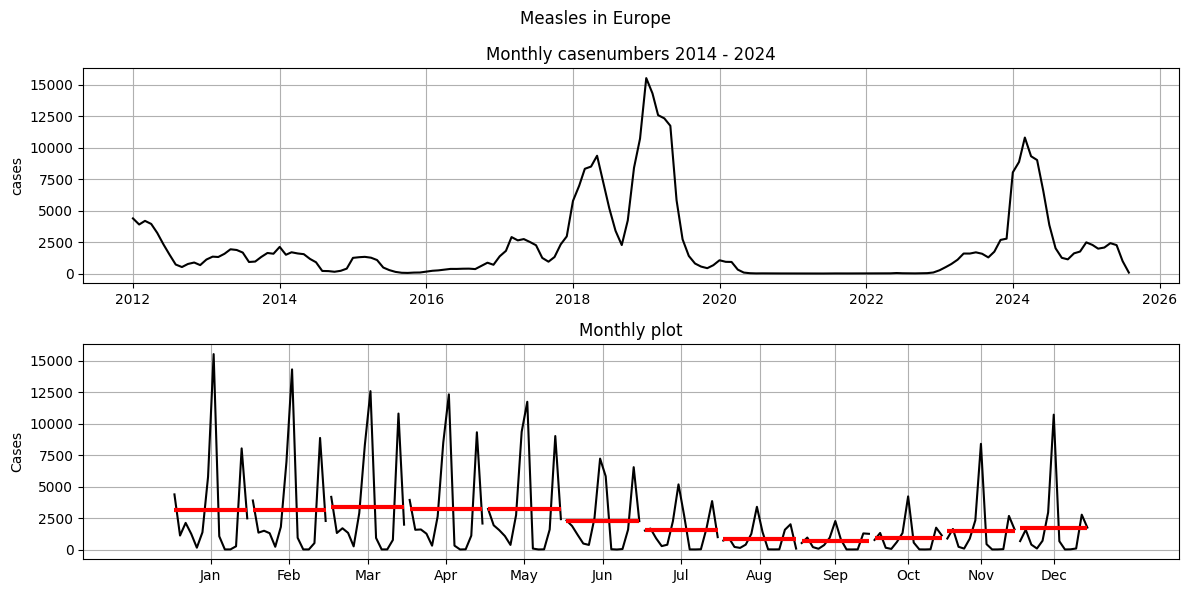

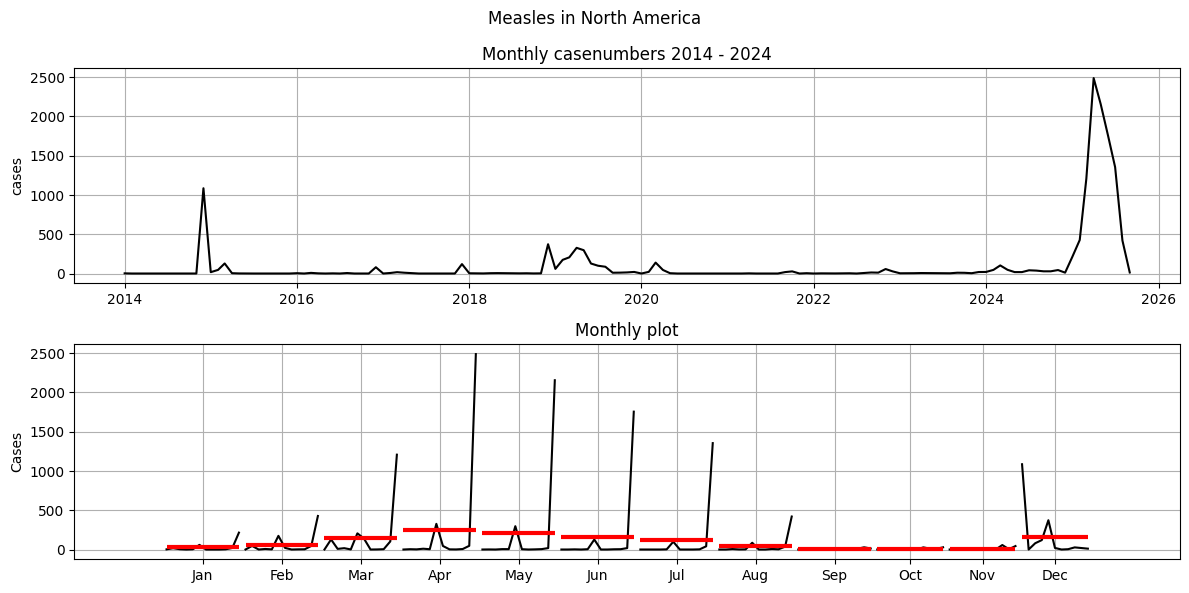

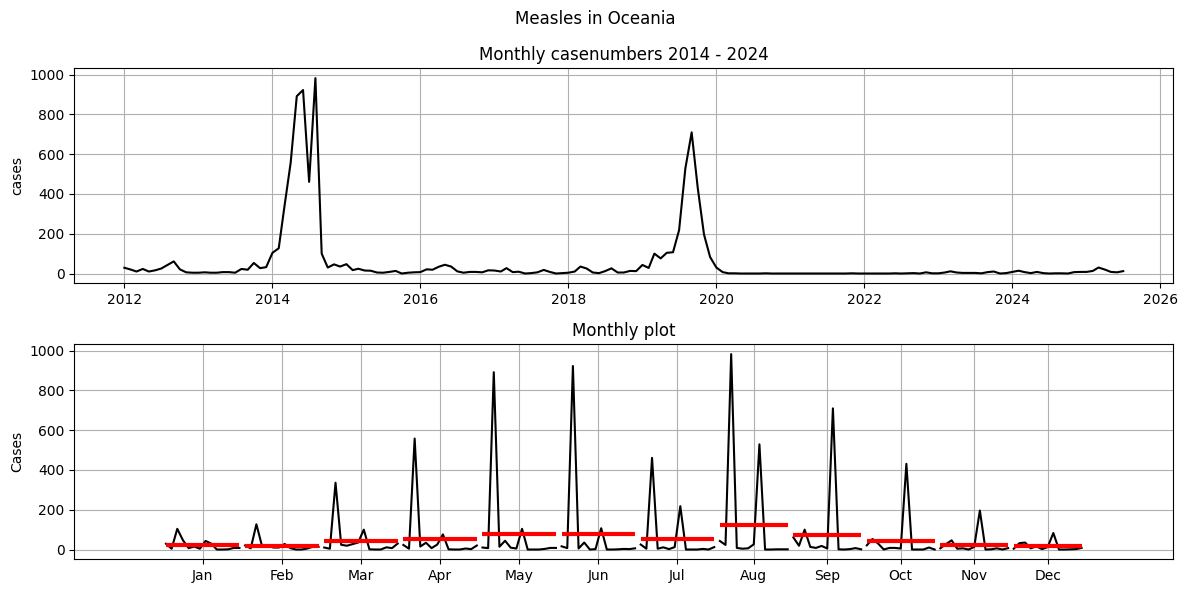

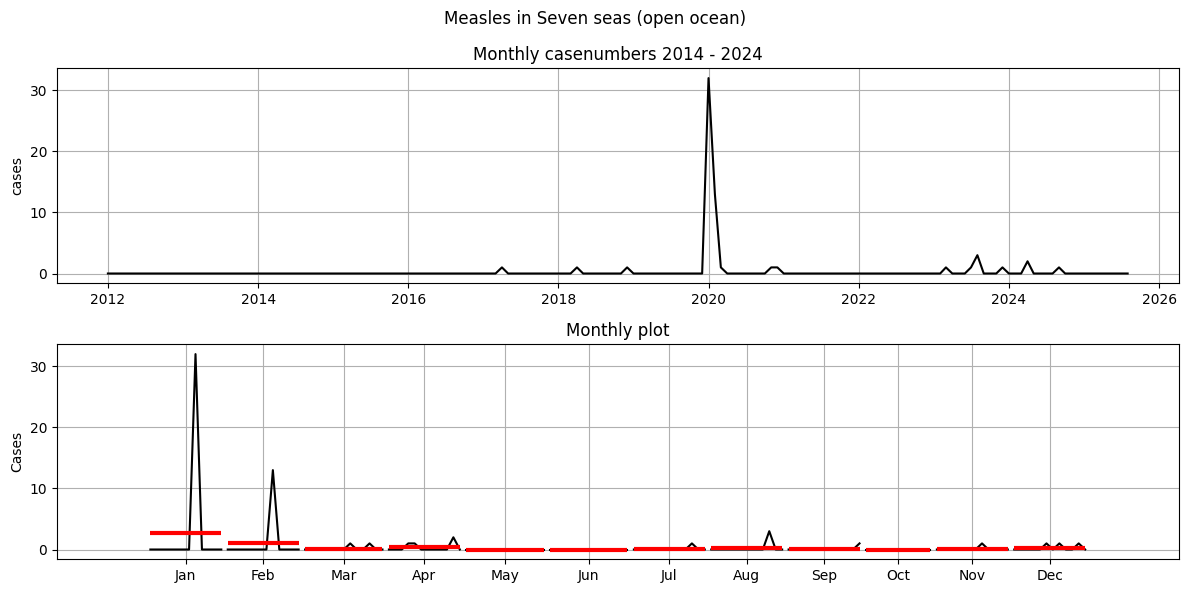

In [16]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot
import seaborn as sns


def plot_monthly_statsmodels(df, title):
    df = df.copy()
    fig, axes = plt.subplots(2, 1, figsize = (12,6))
    axes      = axes.flatten()

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')
    df = df.sort_index()
    
    

    sns.lineplot(df, x = 'timestamp', y ='cases', ax = axes[0], color = 'black')
    axes[0].grid(True)
    axes[0].set_title('Monthly casenumbers 2014 - 2024')
    axes[0].set_xlabel('')
    
    # Convert index to PeriodIndex with monthly freq
    df.index = pd.PeriodIndex(df.index, freq='M')
    ts = df['cases']

    month_plot(ts, ax=axes[1])
    axes[1].grid(True)
    axes[1].set_title(f'Monthly plot')
    axes[1].set_ylabel('Cases')

    plt.suptitle(f'Measles in {title}')

    fig.tight_layout()
    plt.show()



for cc in list(countries_harmfile['continent'].unique()):

    countries = list(countries_harmfile[countries_harmfile['continent'] == cc]['country'].unique())

    df = who_international_casedata.copy()
    df = df[df['country'].isin(countries)]
    df = df.groupby('timestamp')['cases'].sum().reset_index()

    plot_monthly_statsmodels(df, cc)


Excluding 2025 data (incomplete year)


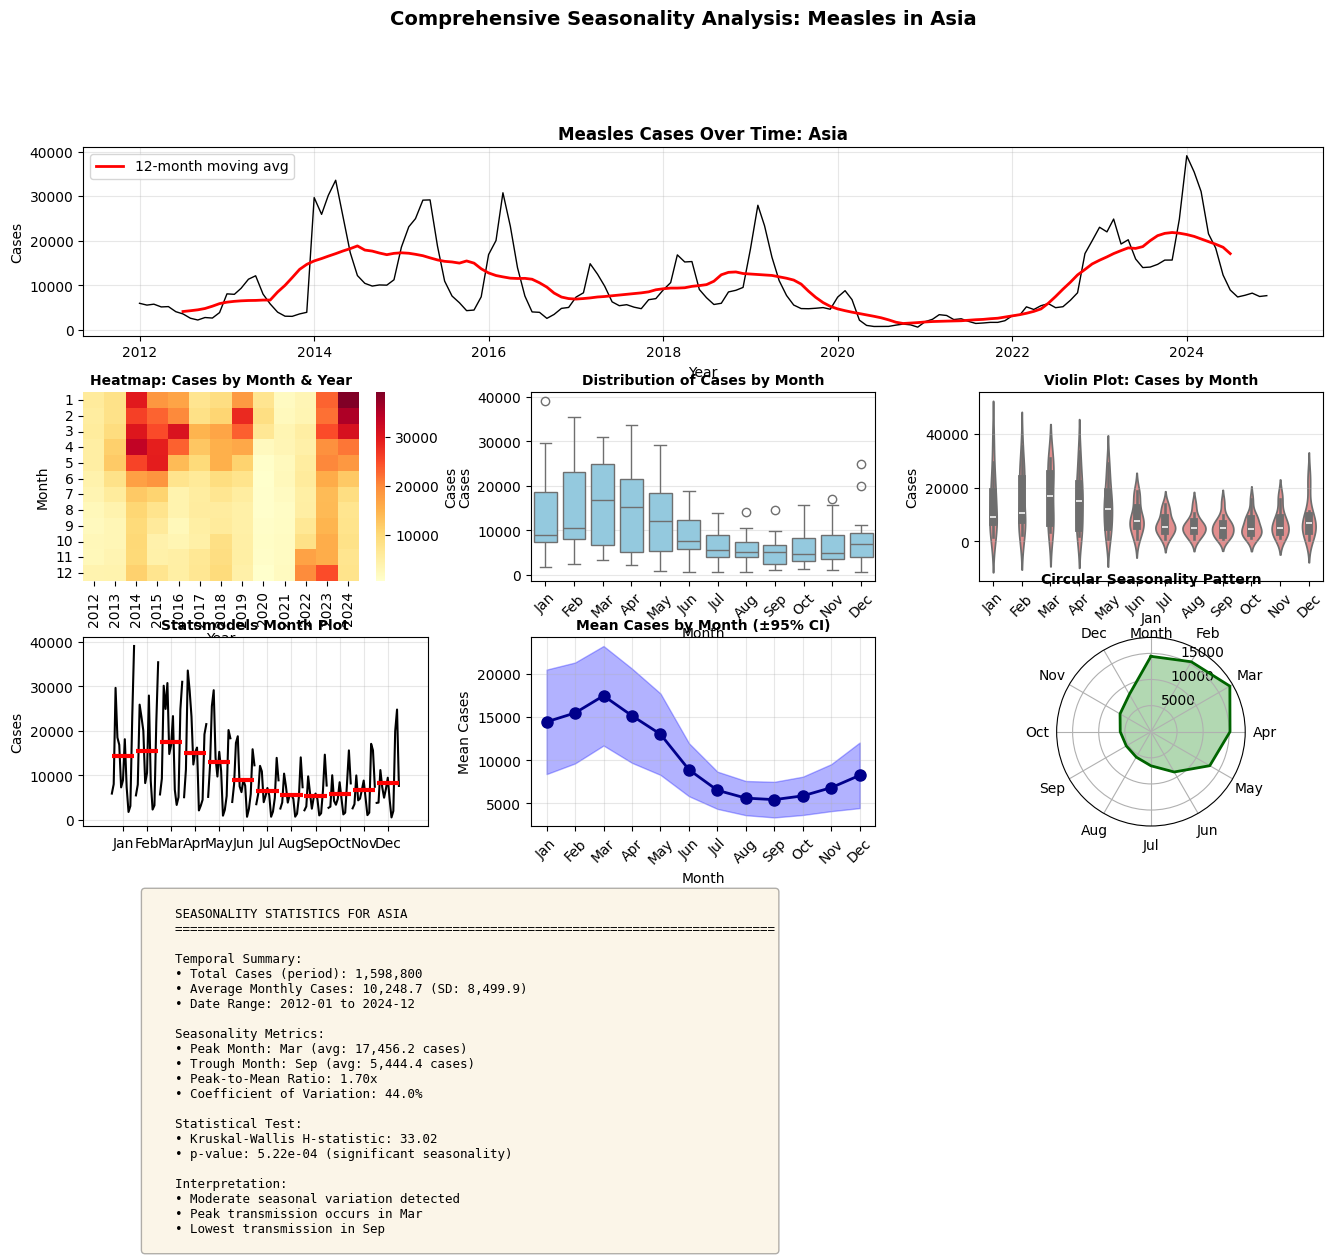


Asia: Peak=3, CV=44.0%
Excluding 2025 data (incomplete year)


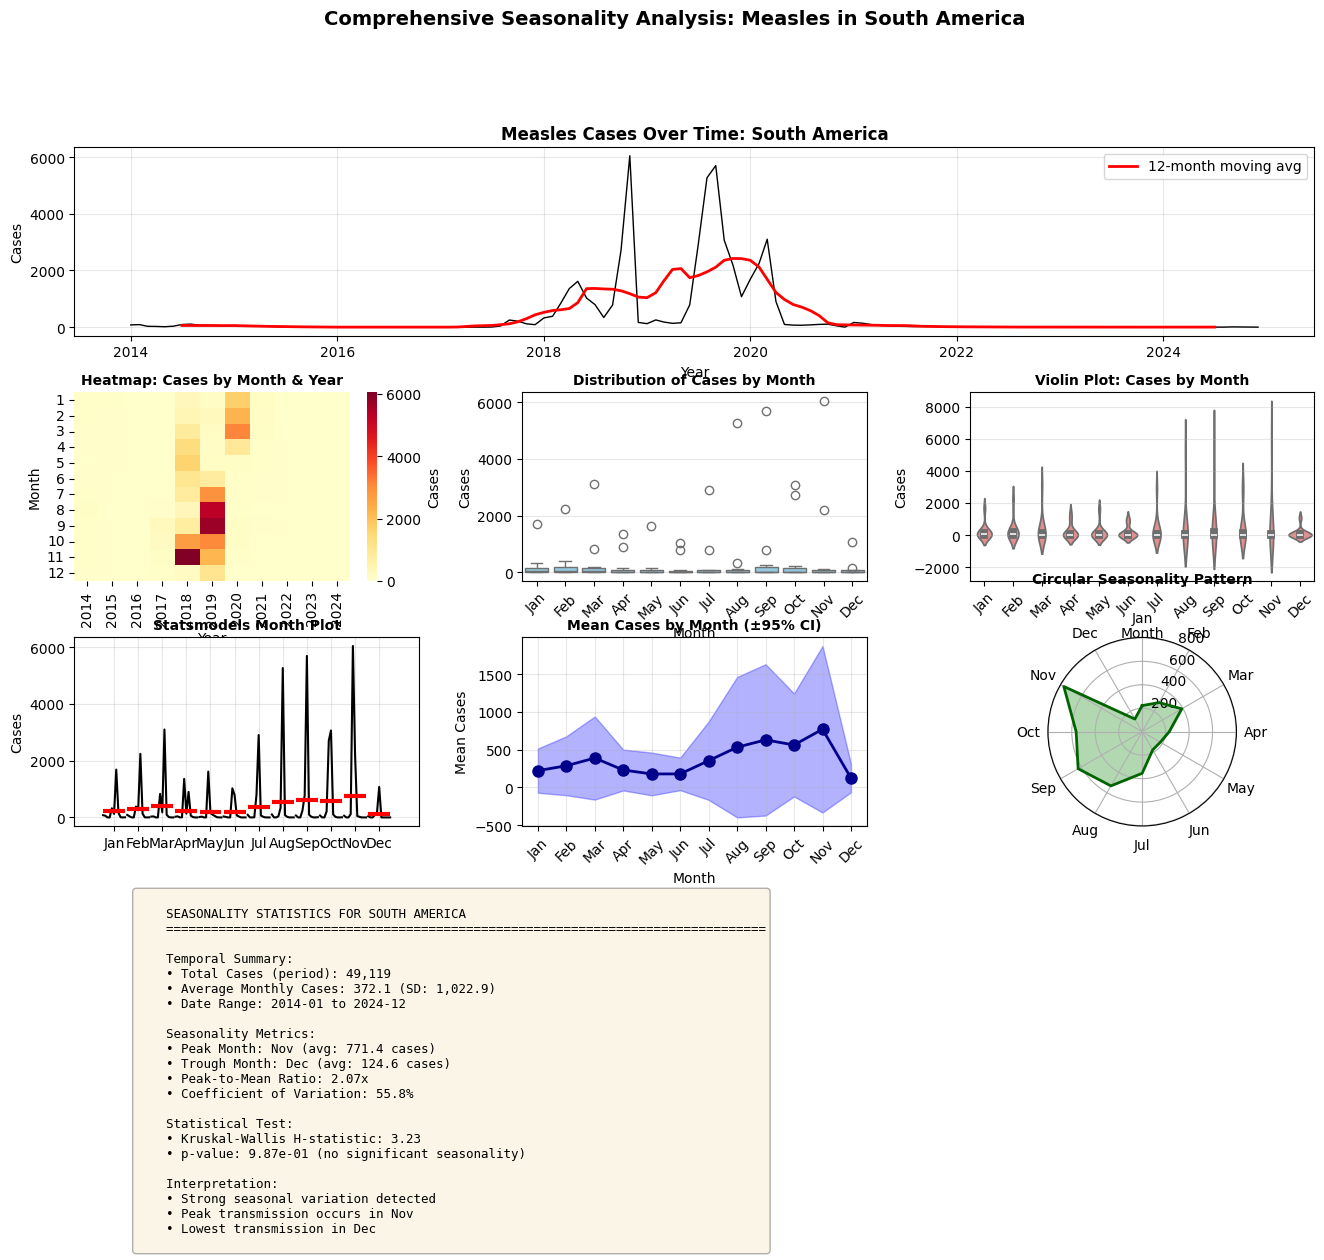


South America: Peak=11, CV=55.8%
Excluding 2025 data (incomplete year)


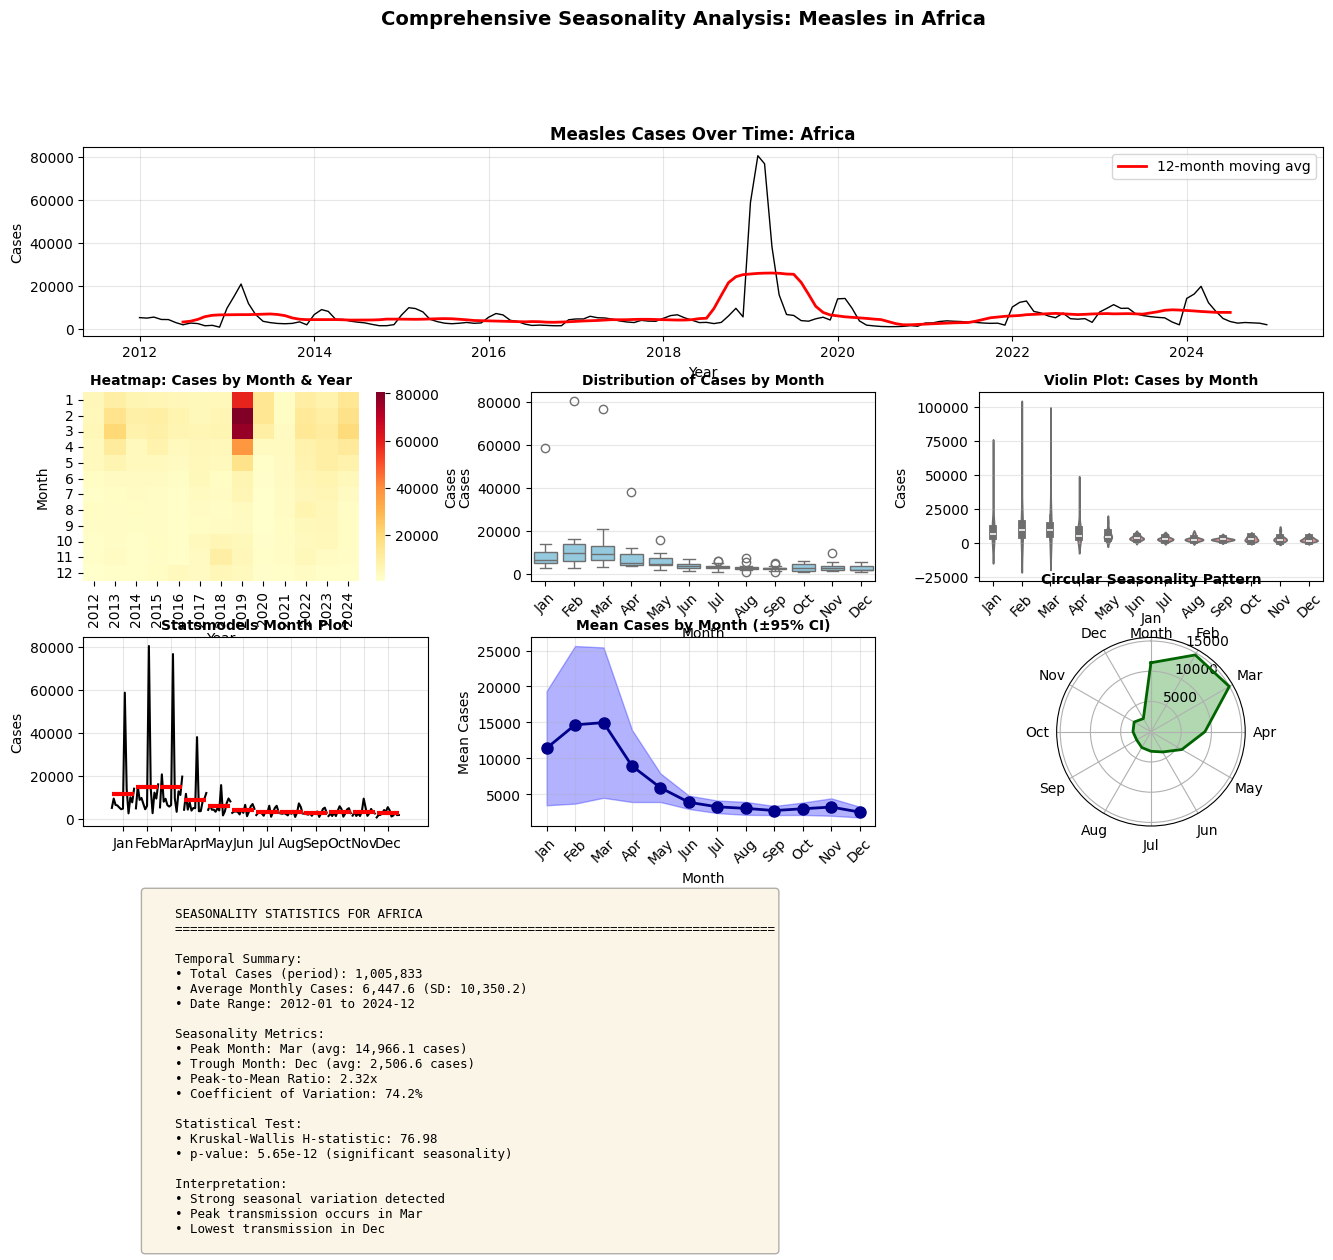


Africa: Peak=3, CV=74.2%
Excluding 2025 data (incomplete year)


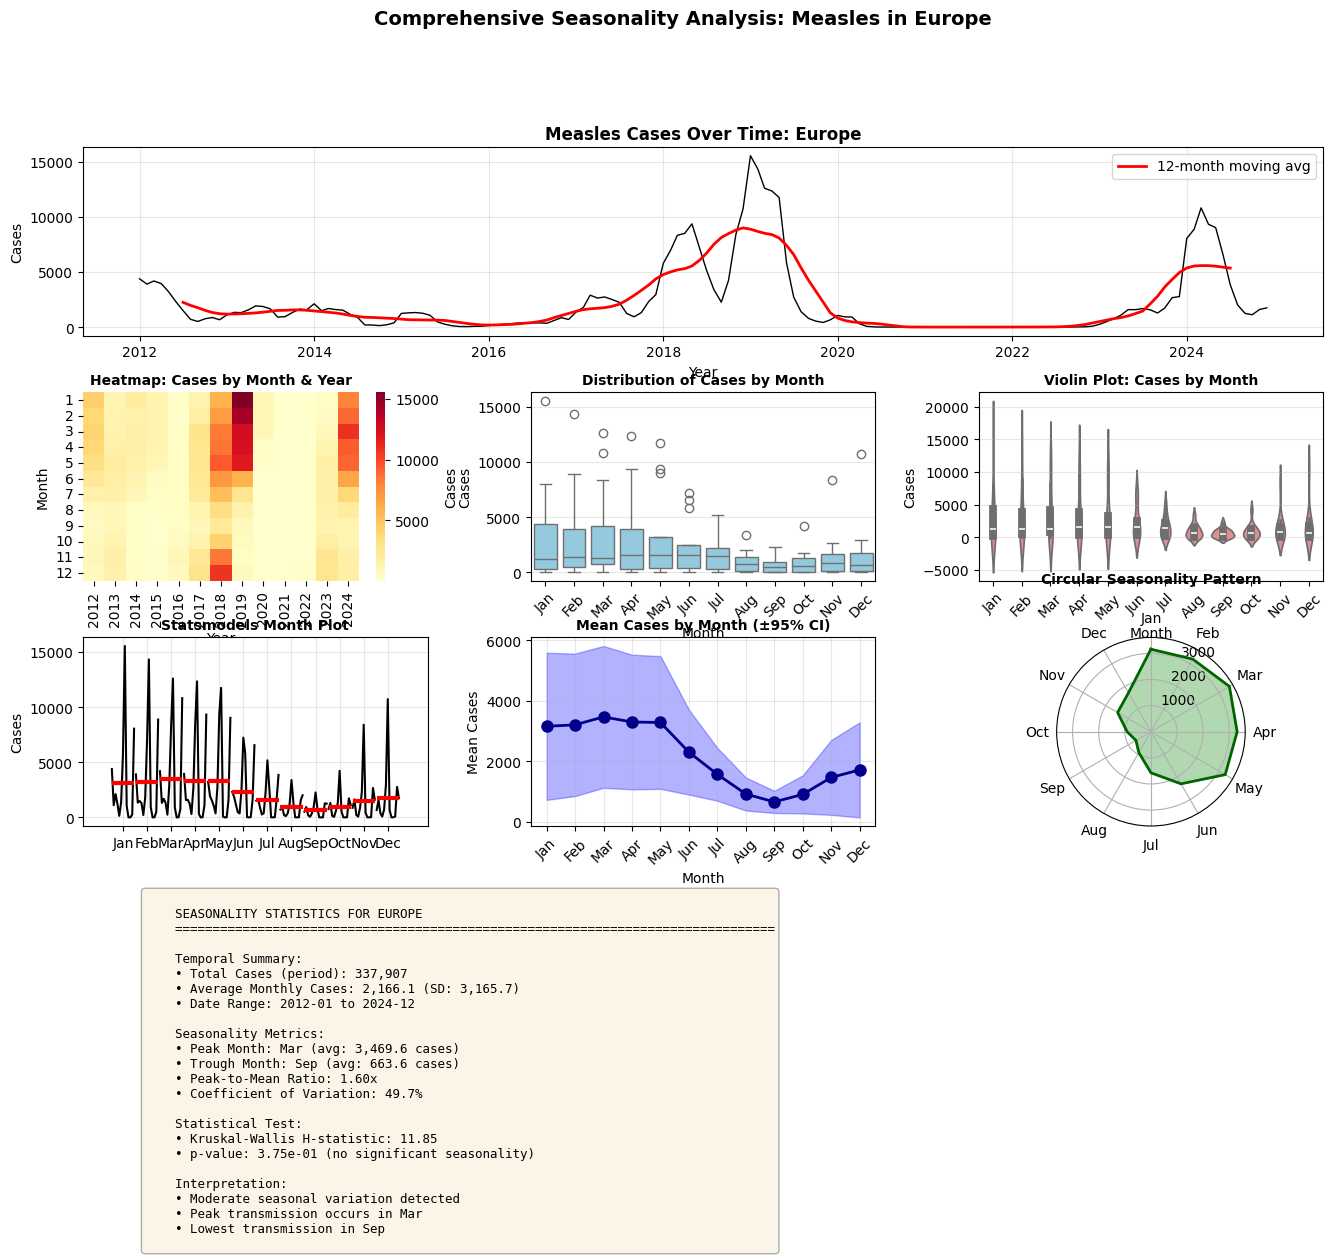


Europe: Peak=3, CV=49.7%
Excluding 2025 data (incomplete year)


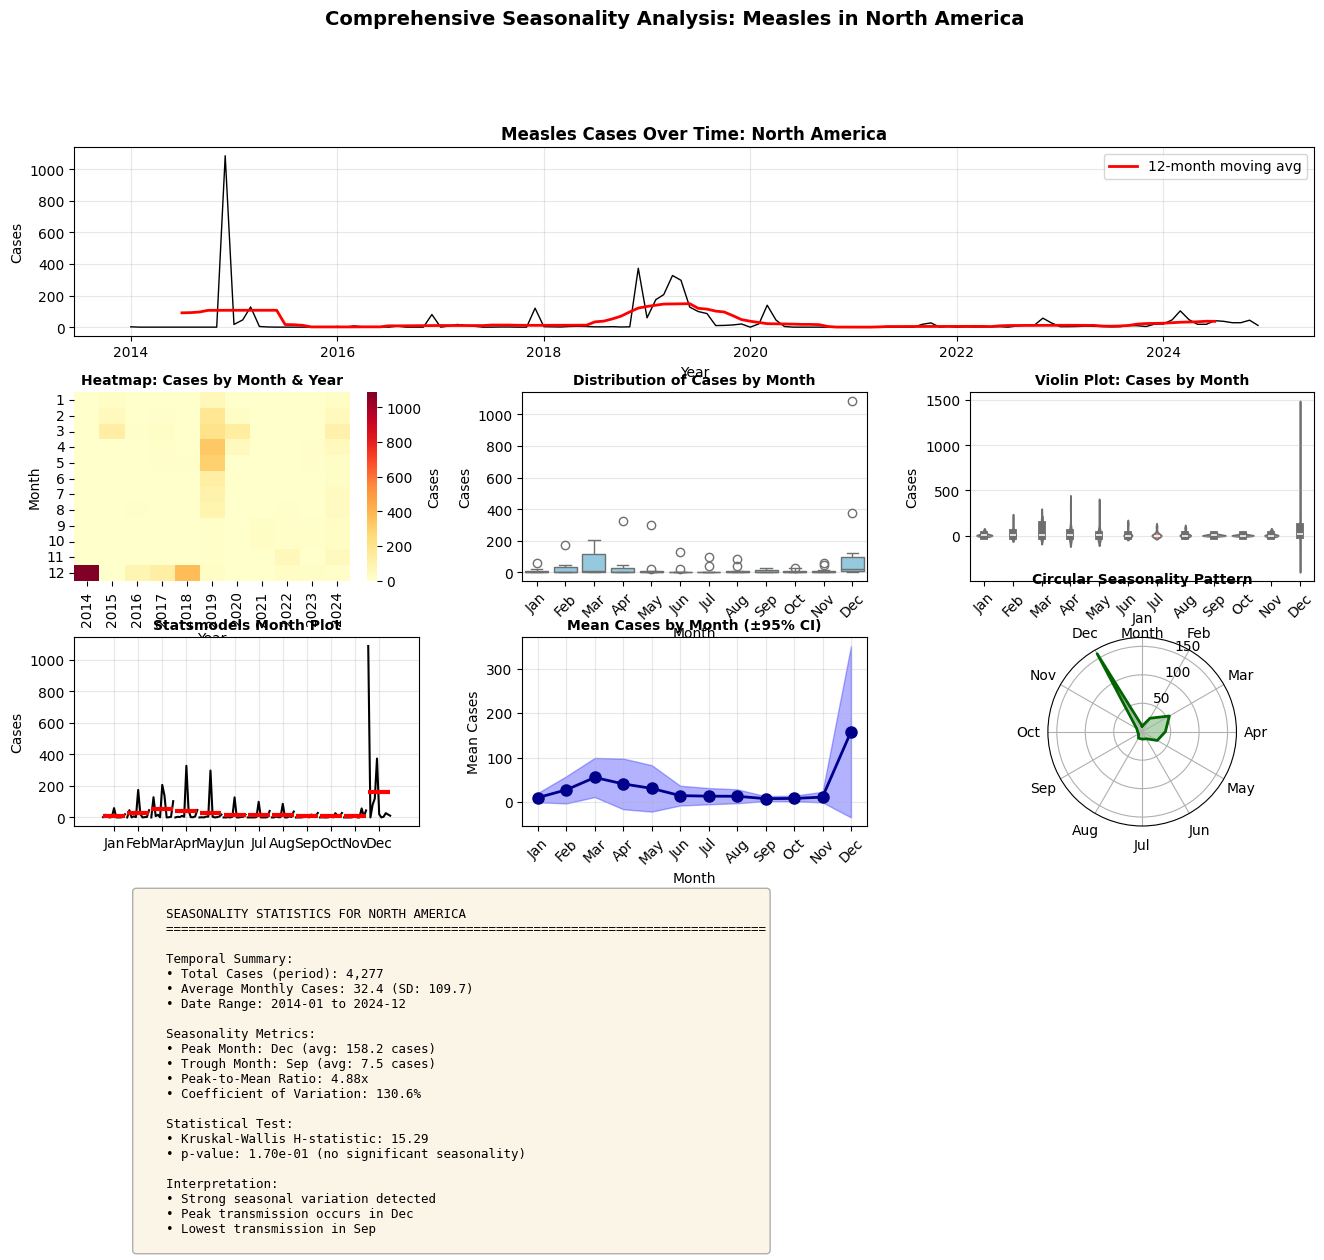


North America: Peak=12, CV=130.6%
Excluding 2025 data (incomplete year)


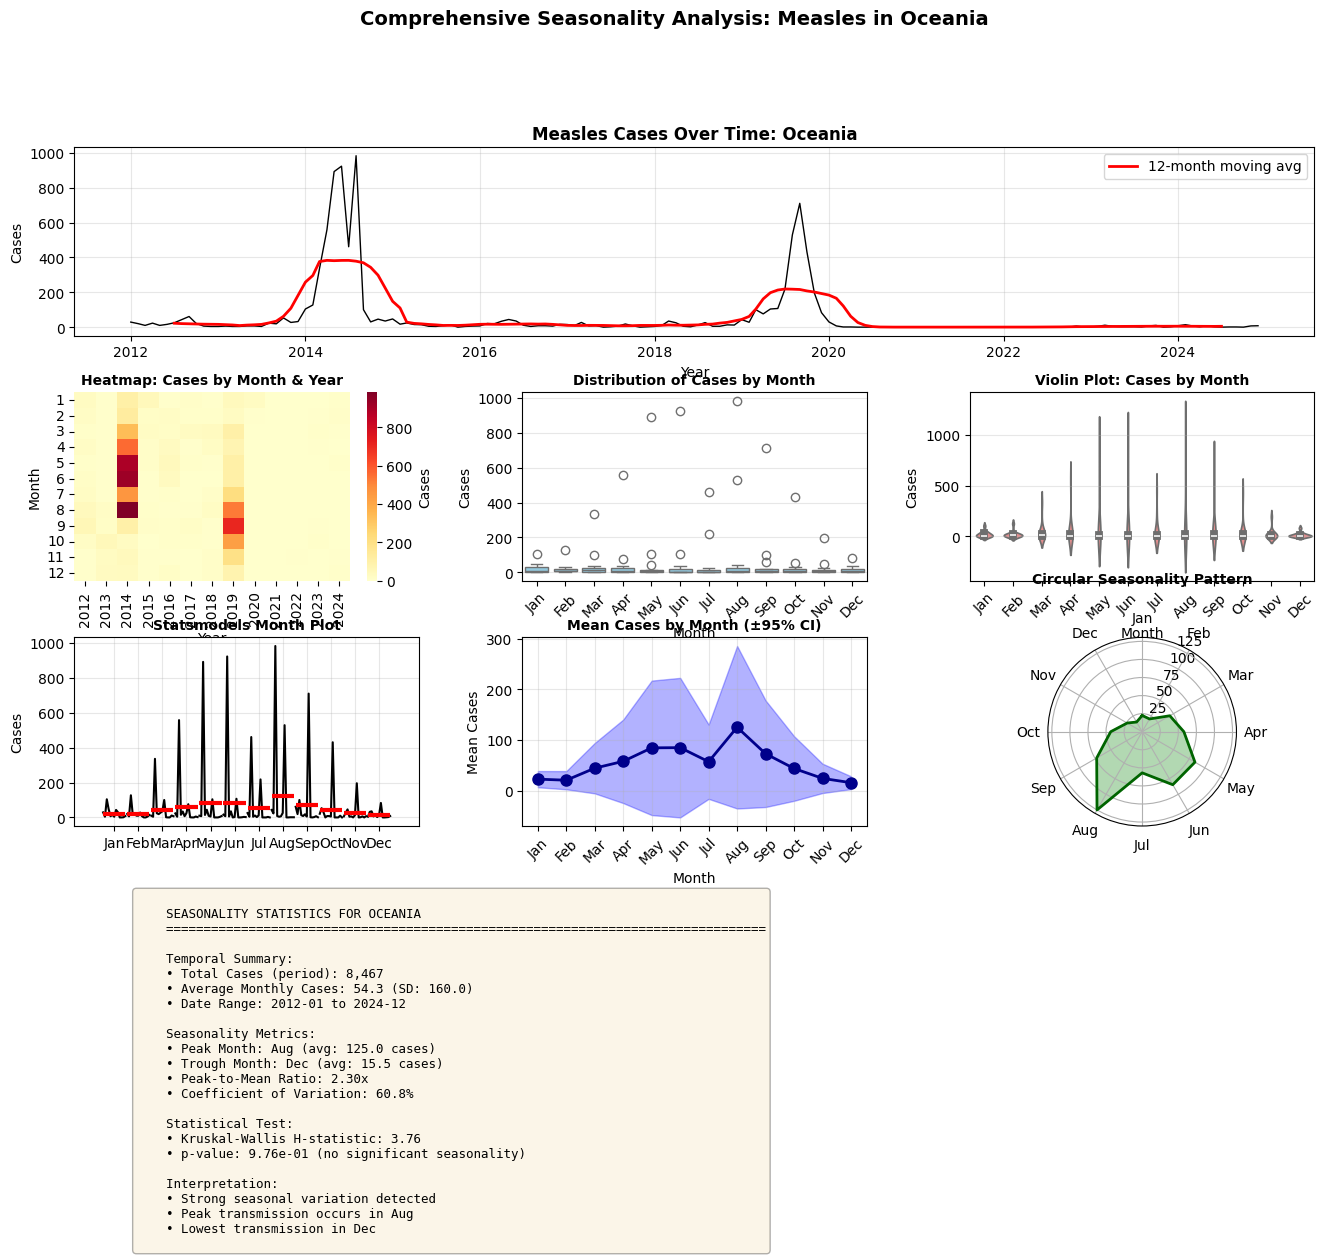


Oceania: Peak=8, CV=60.8%
Excluding 2025 data (incomplete year)


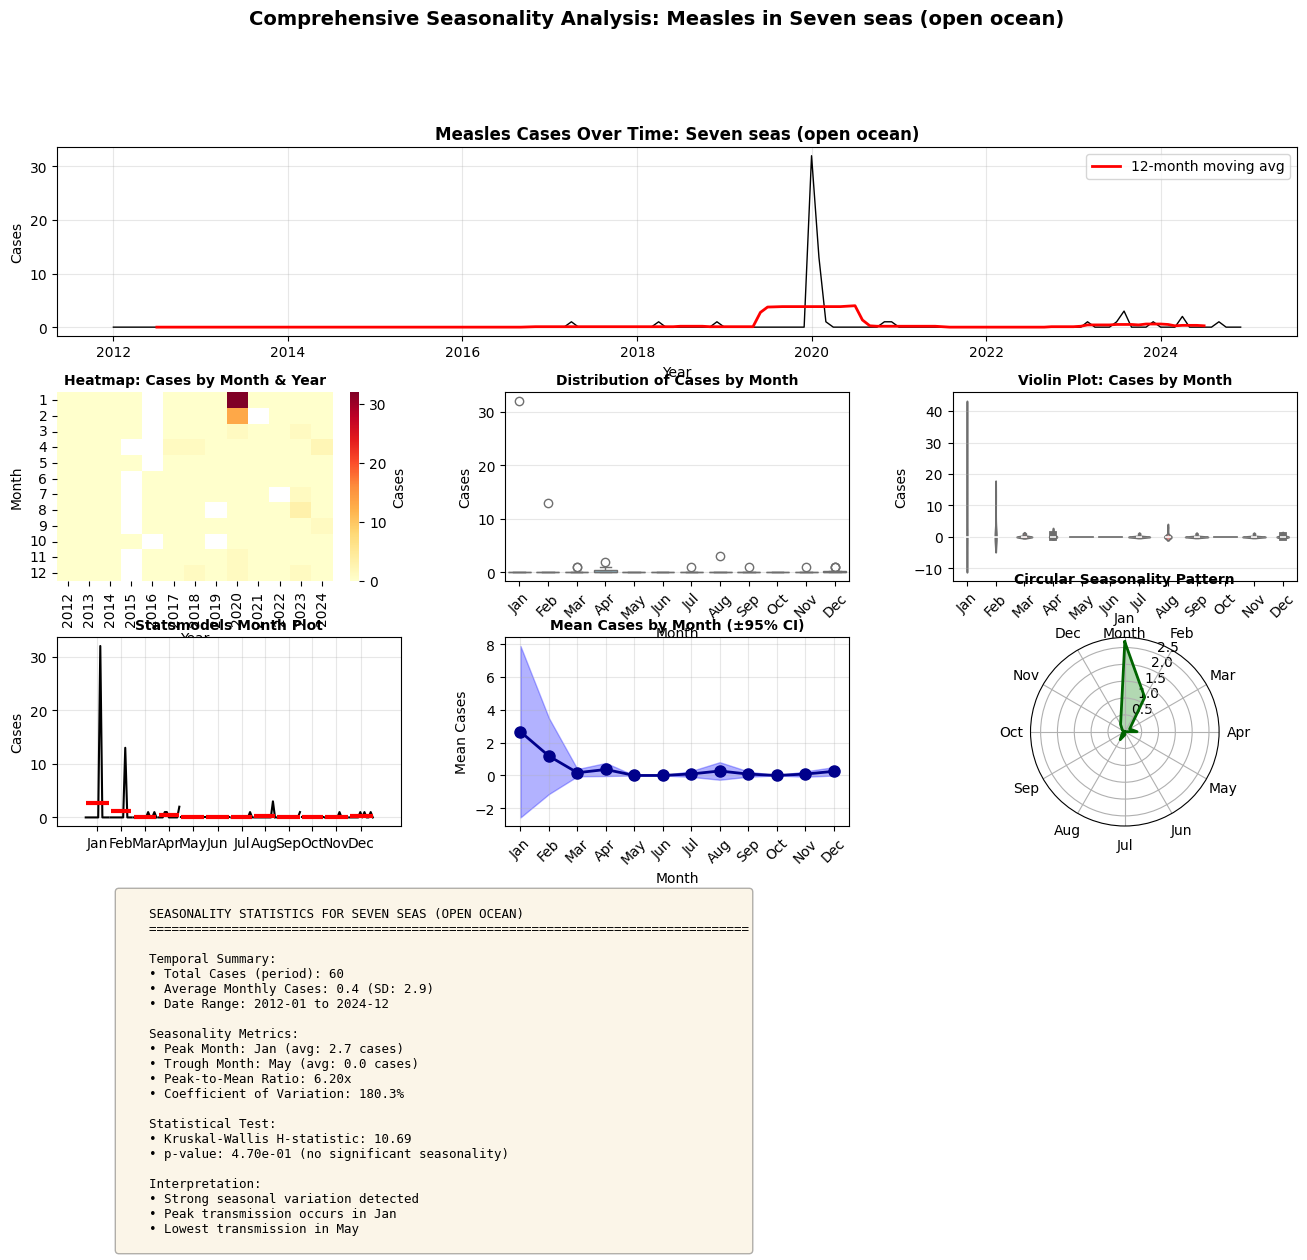


Seven seas (open ocean): Peak=1, CV=180.3%


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from statsmodels.graphics.tsaplots import month_plot


def comprehensive_seasonality_analysis(df, title, save_figs=False, exclude_incomplete_year=True):
    """
    Comprehensive analysis of measles seasonality patterns
    
    Parameters:
    -----------
    df : DataFrame with columns ['timestamp', 'cases']
    title : str, region/continent name
    save_figs : bool, whether to save figures
    exclude_incomplete_year : bool, whether to exclude current incomplete year
    """
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()
    
    # Optionally exclude incomplete current year
    if exclude_incomplete_year:
        current_year = pd.Timestamp.now().year
        df = df[df.index.year < current_year]
        print(f"Excluding {current_year} data (incomplete year)")
    
    # Extract temporal features
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['month_name'] = df.index.strftime('%b')
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
    
    # 1. Time series with trend
    ax1 = fig.add_subplot(gs[0, :])
    sns.lineplot(data=df.reset_index(), x='timestamp', y='cases', ax=ax1, color='black', linewidth=1)
    
    # Add rolling average
    df['rolling_12m'] = df['cases'].rolling(window=12, center=True).mean()
    ax1.plot(df.index, df['rolling_12m'], color='red', linewidth=2, label='12-month moving avg')
    
    ax1.set_title(f'Measles Cases Over Time: {title}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Cases')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Seasonal decomposition plot (monthly patterns by year)
    ax2 = fig.add_subplot(gs[1, 0])
    pivot_data = df.pivot_table(values='cases', index='month', columns='year', aggfunc='sum')
    sns.heatmap(pivot_data, cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Cases'})
    ax2.set_title('Heatmap: Cases by Month & Year', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Year')
    ax2.set_ylabel('Month')
    
    # 3. Box plot by month
    ax3 = fig.add_subplot(gs[1, 1])
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    sns.boxplot(data=df.reset_index(), x='month_name', y='cases', 
                ax=ax3, order=month_order, color='skyblue')
    ax3.set_title('Distribution of Cases by Month', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Month')
    ax3.set_ylabel('Cases')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Violin plot by month
    ax4 = fig.add_subplot(gs[1, 2])
    sns.violinplot(data=df.reset_index(), x='month_name', y='cases', 
                   ax=ax4, order=month_order, color='lightcoral')
    ax4.set_title('Violin Plot: Cases by Month', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Month')
    ax4.set_ylabel('Cases')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 5. Statsmodels month plot
    ax5 = fig.add_subplot(gs[2, 0])
    df_period = df.copy()
    df_period.index = pd.PeriodIndex(df_period.index, freq='M')
    month_plot(df_period['cases'], ax=ax5)
    ax5.set_title('Statsmodels Month Plot', fontsize=10, fontweight='bold')
    ax5.set_ylabel('Cases')
    ax5.grid(True, alpha=0.3)
    
    # 6. Mean cases by month with confidence intervals
    ax6 = fig.add_subplot(gs[2, 1])
    monthly_stats = df.groupby('month')['cases'].agg(['mean', 'std', 'count'])
    monthly_stats['se'] = monthly_stats['std'] / np.sqrt(monthly_stats['count'])
    monthly_stats['ci'] = 1.96 * monthly_stats['se']
    
    x = monthly_stats.index
    ax6.plot(x, monthly_stats['mean'], marker='o', linewidth=2, markersize=8, color='darkblue')
    ax6.fill_between(x, 
                     monthly_stats['mean'] - monthly_stats['ci'],
                     monthly_stats['mean'] + monthly_stats['ci'],
                     alpha=0.3, color='blue')
    ax6.set_title('Mean Cases by Month (±95% CI)', fontsize=10, fontweight='bold')
    ax6.set_xlabel('Month')
    ax6.set_ylabel('Mean Cases')
    ax6.set_xticks(range(1, 13))
    ax6.set_xticklabels(month_order)
    ax6.tick_params(axis='x', rotation=45)
    ax6.grid(True, alpha=0.3)
    
    # 7. Polar plot of monthly averages
    ax7 = fig.add_subplot(gs[2, 2], projection='polar')
    theta = np.linspace(0, 2 * np.pi, 13)
    monthly_mean = df.groupby('month')['cases'].mean()
    r = list(monthly_mean.values) + [monthly_mean.values[0]]  # Close the circle
    
    ax7.plot(theta, r, linewidth=2, color='darkgreen')
    ax7.fill(theta, r, alpha=0.3, color='green')
    ax7.set_theta_zero_location('N')
    ax7.set_theta_direction(-1)
    ax7.set_xticks(theta[:-1])
    ax7.set_xticklabels(month_order)
    ax7.set_title('Circular Seasonality Pattern', fontsize=10, fontweight='bold', pad=20)
    
    # 8. Statistical summary
    ax8 = fig.add_subplot(gs[3, :])
    ax8.axis('off')
    
    # Calculate seasonality metrics
    monthly_avg = df.groupby('month')['cases'].mean()
    peak_month = monthly_avg.idxmax()
    trough_month = monthly_avg.idxmin()
    seasonality_ratio = monthly_avg.max() / monthly_avg.mean() if monthly_avg.mean() > 0 else 0
    
    # Calculate coefficient of variation
    cv = (monthly_avg.std() / monthly_avg.mean() * 100) if monthly_avg.mean() > 0 else 0
    
    # Perform Kruskal-Wallis test (non-parametric test for differences across months)
    month_groups = [df[df['month'] == m]['cases'].values for m in range(1, 13)]
    kw_stat, kw_pval = kruskal(*month_groups)
    
    # Calculate total cases
    total_cases = df['cases'].sum()
    avg_monthly = df['cases'].mean()
    
    stats_text = f"""
    SEASONALITY STATISTICS FOR {title.upper()}
    {'='*80}
    
    Temporal Summary:
    • Total Cases (period): {total_cases:,.0f}
    • Average Monthly Cases: {avg_monthly:,.1f} (SD: {df['cases'].std():,.1f})
    • Date Range: {df.index.min().strftime('%Y-%m')} to {df.index.max().strftime('%Y-%m')}
    
    Seasonality Metrics:
    • Peak Month: {month_order[peak_month-1]} (avg: {monthly_avg.max():,.1f} cases)
    • Trough Month: {month_order[trough_month-1]} (avg: {monthly_avg.min():,.1f} cases)
    • Peak-to-Mean Ratio: {seasonality_ratio:.2f}x
    • Coefficient of Variation: {cv:.1f}%
    
    Statistical Test:
    • Kruskal-Wallis H-statistic: {kw_stat:.2f}
    • p-value: {kw_pval:.2e} {'(significant seasonality)' if kw_pval < 0.05 else '(no significant seasonality)'}
    
    Interpretation:
    • {'Strong' if cv > 50 else 'Moderate' if cv > 30 else 'Weak'} seasonal variation detected
    • Peak transmission occurs in {month_order[peak_month-1]}
    • Lowest transmission in {month_order[trough_month-1]}
    """
    
    ax8.text(0.05, 0.95, stats_text, transform=ax8.transAxes,
             fontsize=9, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(f'Comprehensive Seasonality Analysis: Measles in {title}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    if save_figs:
        plt.savefig(f'measles_seasonality_{title.replace(" ", "_")}.png', 
                    dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return {
        'peak_month': peak_month,
        'trough_month': trough_month,
        'seasonality_ratio': seasonality_ratio,
        'cv': cv,
        'kw_pvalue': kw_pval
    }


# Usage example with your data
for cc in list(countries_harmfile['continent'].unique()):
    countries = list(countries_harmfile[countries_harmfile['continent'] == cc]['country'].unique())
    
    df = who_international_casedata.copy()
    df = df[df['country'].isin(countries)]
    df = df.groupby('timestamp')['cases'].sum().reset_index()
    
    # Run comprehensive analysis (will exclude 2025 by default)
    result_stats = comprehensive_seasonality_analysis(df, cc, save_figs=False)
    print(f"\n{cc}: Peak={result_stats['peak_month']}, CV={result_stats['cv']:.1f}%")

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import kruskal
from statsmodels.graphics.tsaplots import month_plot

def comprehensive_seasonality_analysis(df, title, save_figs=False, exclude_incomplete_year=True):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()
    
    if exclude_incomplete_year:
        current_year = pd.Timestamp.now().year
        df = df[df.index.year < current_year]
    
    if df.empty or df['cases'].sum() == 0:
        print(f"⚠️ No data for {title}. Skipping.")
        return None
    
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['month_name'] = df.index.strftime('%b')
    
    monthly_avg = df.groupby('month')['cases'].mean()
    peak_month = monthly_avg.idxmax()
    trough_month = monthly_avg.idxmin()
    seasonality_ratio = monthly_avg.max() / monthly_avg.mean() if monthly_avg.mean() > 0 else 0
    cv = (monthly_avg.std() / monthly_avg.mean() * 100) if monthly_avg.mean() > 0 else 0
    month_groups = [df[df['month'] == m]['cases'].values for m in range(1, 13)]
    kw_stat, kw_pval = kruskal(*month_groups)
    
    return {
        'country': title,
        'peak_month': peak_month,
        'trough_month': trough_month,
        'seasonality_ratio': seasonality_ratio,
        'cv': cv,
        'kw_pvalue': kw_pval,
        'total_cases': df['cases'].sum()
    }

# Run the national-level analysis
all_country_results = []

for country in sorted(who_international_casedata['country'].unique()):
    df_country = who_international_casedata[who_international_casedata['country'] == country]
    if df_country.empty:
        continue

    df_country = df_country.groupby('timestamp')['cases'].sum().reset_index()
    result = comprehensive_seasonality_analysis(df_country, title=country, save_figs=False)

    if result:
        all_country_results.append(result)

# Create dataframe of national results
country_stats_df = pd.DataFrame(all_country_results)

# Merge in region/continent info
meta = countries_harmfile[['country', 'continent', 'region']].drop_duplicates()
country_stats_df = country_stats_df.merge(meta, on='country', how='left')

# Regional summary
regional_summary = (
    country_stats_df
    .groupby('continent')
    .agg(
        n_countries=('country', 'count'),
        median_peak_month=('peak_month', 'median'),
        mean_cv=('cv', 'mean'),
        mean_kw_pvalue=('kw_pvalue', 'mean'),
        mean_seasonality_ratio=('seasonality_ratio', 'mean')
    )
    .reset_index()
)

print("\n🌍 Regional Summary of Seasonality Metrics:")
print(regional_summary.to_string(index=False, float_format="%.2f"))


⚠️ No data for Andorra. Skipping.
⚠️ No data for Barbados. Skipping.
⚠️ No data for Belize. Skipping.
⚠️ No data for Dominica. Skipping.
⚠️ No data for Dominican Republic. Skipping.
⚠️ No data for El Salvador. Skipping.
⚠️ No data for Grenada. Skipping.
⚠️ No data for Guyana. Skipping.
⚠️ No data for Haiti. Skipping.
⚠️ No data for Honduras. Skipping.
⚠️ No data for Jamaica. Skipping.
⚠️ No data for Kiribati. Skipping.
⚠️ No data for Marshall Islands. Skipping.
⚠️ No data for Nauru. Skipping.
⚠️ No data for Nicaragua. Skipping.
⚠️ No data for Palau. Skipping.
⚠️ No data for Panama. Skipping.
⚠️ No data for Saint Kitts and Nevis. Skipping.
⚠️ No data for Saint Vincent and the Grenadines. Skipping.
⚠️ No data for Suriname. Skipping.
⚠️ No data for Trinidad and Tobago. Skipping.
⚠️ No data for Turkmenistan. Skipping.
⚠️ No data for Tuvalu. Skipping.

🌍 Regional Summary of Seasonality Metrics:
              continent  n_countries  median_peak_month  mean_cv  mean_kw_pvalue  mean_seasonalit

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import circmean, circstd
from scipy.stats import f_oneway  # or nonparametric alternatives
import matplotlib.pyplot as plt

def circular_stats_by_group(country_stats_df, group_col='continent'):
    # Convert peak_month to radians (0–2π)
    country_stats_df = country_stats_df.copy()
    country_stats_df['peak_rad'] = (country_stats_df['peak_month'] % 12) * (2 * np.pi / 12)
    
    groups = country_stats_df.groupby(group_col)
    results = []
    
    for grp, sub in groups:
        if len(sub) < 2:
            continue
        angles = sub['peak_rad'].values
        mean_angle = circmean(angles, high=2*np.pi, low=0)
        std_dev = circstd(angles, high=2*np.pi, low=0)
        results.append((grp, len(sub), mean_angle, std_dev))
    
    res_df = pd.DataFrame(results, columns=[group_col, 'n', 'mean_angle', 'circ_std'])
    res_df['mean_month'] = res_df['mean_angle'] * 12 / (2 * np.pi)
    return res_df

circ_df = circular_stats_by_group(country_stats_df, 'continent')
print(circ_df)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.stats import kruskal, circmean, circstd
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')


def calculate_outbreak_threshold(df, method='iqr', multiplier=1.5):
    """
    Calculate threshold for outbreak detection
    
    Parameters:
    -----------
    method : str, 'iqr' (interquartile range) or 'percentile' or 'zscore'
    multiplier : float, for IQR method
    """
    if method == 'iqr':
        Q1 = df['cases'].quantile(0.25)
        Q3 = df['cases'].quantile(0.75)
        IQR = Q3 - Q1
        threshold = Q3 + multiplier * IQR
    elif method == 'percentile':
        threshold = df['cases'].quantile(0.90)
    elif method == 'zscore':
        threshold = df['cases'].mean() + 2 * df['cases'].std()
    
    return threshold


def normalize_by_country_year(df_long, countries_harmfile):
    """
    Normalize cases by country-year to handle different baseline incidence rates
    
    Parameters:
    -----------
    df_long : DataFrame with columns ['country', 'timestamp', 'cases']
    countries_harmfile : DataFrame with country metadata
    
    Returns:
    --------
    DataFrame with normalized cases
    """
    df = df_long.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    
    # Calculate country-year baselines (median to be robust to outbreaks)
    country_year_baseline = df.groupby(['country', 'year'])['cases'].transform('median')
    
    # Normalize: cases as proportion of country-year baseline
    df['cases_normalized'] = df['cases'] / (country_year_baseline + 1)  # +1 to avoid division by zero
    
    return df


def analyze_regional_seasonality(who_data, countries_harmfile, 
                                 exclude_outbreaks=True, 
                                 outbreak_threshold_method='percentile',
                                 exclude_incomplete_year=True):
    """
    Analyze seasonality patterns across WHO regions with outbreak handling
    
    Parameters:
    -----------
    who_data : DataFrame with ['country', 'timestamp', 'cases']
    countries_harmfile : DataFrame with ['country', 'region'] (and optionally 'continent')
    exclude_outbreaks : bool, whether to exclude outbreak months
    outbreak_threshold_method : str, method for outbreak detection
    """
    
    df = who_data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Exclude incomplete year
    if exclude_incomplete_year:
        current_year = pd.Timestamp.now().year
        df = df[df['timestamp'].dt.year < current_year]
    
    # Merge with region info
    df = df.merge(countries_harmfile[['country', 'region']], on='country', how='left')
    df = df.dropna(subset=['region'])
    
    # Add temporal features
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['month_name'] = df['timestamp'].dt.strftime('%b')
    
    # Normalize by country-year baseline
    df_norm = normalize_by_country_year(df, countries_harmfile)
    
    results = []
    
    for region in sorted(df_norm['region'].unique()):
        region_data = df_norm[df_norm['region'] == region].copy()
        
        if exclude_outbreaks:
            # Calculate outbreak threshold per country
            threshold = calculate_outbreak_threshold(region_data, method=outbreak_threshold_method)
            region_data_clean = region_data[region_data['cases'] <= threshold].copy()
            n_excluded = len(region_data) - len(region_data_clean)
            pct_excluded = 100 * n_excluded / len(region_data)
        else:
            region_data_clean = region_data.copy()
            n_excluded = 0
            pct_excluded = 0
        
        # Calculate monthly statistics on NORMALIZED data
        monthly_stats = region_data_clean.groupby('month').agg({
            'cases_normalized': ['mean', 'median', 'std', 'count']
        }).reset_index()
        monthly_stats.columns = ['month', 'mean_norm', 'median_norm', 'std_norm', 'count']
        
        # Also get raw case statistics
        monthly_raw = region_data_clean.groupby('month')['cases'].agg(['mean', 'median']).reset_index()
        monthly_stats = monthly_stats.merge(monthly_raw, on='month')
        
        # Calculate metrics
        peak_month = monthly_stats.loc[monthly_stats['mean_norm'].idxmax(), 'month']
        trough_month = monthly_stats.loc[monthly_stats['mean_norm'].idxmin(), 'month']
        
        cv = (monthly_stats['mean_norm'].std() / monthly_stats['mean_norm'].mean() * 100) if monthly_stats['mean_norm'].mean() > 0 else 0
        
        # Circular statistics for peak timing
        # Convert months to angles (radians) and calculate weighted mean manually
        angles = monthly_stats['month'].values * (2 * np.pi / 12)
        weights = monthly_stats['mean_norm'].values
        
        # Manual weighted circular mean calculation
        sin_sum = np.sum(weights * np.sin(angles))
        cos_sum = np.sum(weights * np.cos(angles))
        mean_angle = np.arctan2(sin_sum, cos_sum)
        if mean_angle < 0:
            mean_angle += 2 * np.pi
        
        mean_month = (mean_angle * 12 / (2 * np.pi))
        if mean_month < 1:
            mean_month += 12
        
        # Kruskal-Wallis test on normalized data
        month_groups = [region_data_clean[region_data_clean['month'] == m]['cases_normalized'].values 
                       for m in range(1, 13)]
        
        # Check if we have enough variation for the test
        all_values = np.concatenate([g for g in month_groups if len(g) > 0])
        has_variation = len(np.unique(all_values)) > 1
        
        if all(len(g) > 0 for g in month_groups) and has_variation:
            try:
                kw_stat, kw_pval = kruskal(*month_groups)
            except ValueError:
                # All values identical or other issue
                kw_stat, kw_pval = np.nan, np.nan
        else:
            kw_stat, kw_pval = np.nan, np.nan
        
        results.append({
            'region': region,
            'peak_month': int(peak_month),
            'trough_month': int(trough_month),
            'mean_peak_month': mean_month,
            'cv': cv,
            'kw_pvalue': kw_pval,
            'n_months': len(region_data_clean),
            'n_excluded': n_excluded,
            'pct_excluded': pct_excluded,
            'total_cases': region_data['cases'].sum(),
            'monthly_pattern': monthly_stats
        })
    
    return pd.DataFrame(results)


def plot_regional_comparison(results_df):
    """
    Create comprehensive comparison plot across regions
    """
    n_regions = len(results_df)
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # Create figure
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(4, 5, hspace=0.4, wspace=0.4)
    
    # 1. Heatmap of normalized seasonality patterns
    ax1 = fig.add_subplot(gs[0:2, 0:3])
    
    heatmap_data = []
    region_labels = []
    for idx, row in results_df.iterrows():
        monthly = row['monthly_pattern']
        # Ensure we have all 12 months, fill missing with NaN
        values = np.full(12, np.nan)
        for i, month_val in enumerate(monthly['month'].values):
            values[int(month_val)-1] = monthly['mean_norm'].values[i]
        
        # Normalize to 0-1 scale for each region (only for non-NaN values)
        valid_mask = ~np.isnan(values)
        if valid_mask.sum() > 0:
            valid_values = values[valid_mask]
            val_min, val_max = valid_values.min(), valid_values.max()
            if val_max > val_min:
                values_scaled = np.where(valid_mask, 
                                        (values - val_min) / (val_max - val_min), 
                                        np.nan)
            else:
                values_scaled = np.where(valid_mask, 0.5, np.nan)
        else:
            values_scaled = values
            
        heatmap_data.append(values_scaled)
        region_labels.append(row['region'])
    
    heatmap_data = np.array(heatmap_data)
    sns.heatmap(heatmap_data, xticklabels=month_names, yticklabels=region_labels,
                cmap='RdYlGn_r', ax=ax1, cbar_kws={'label': 'Relative Incidence\n(0=min, 1=max)'})
    ax1.set_title('Seasonality Patterns by Region (Normalized)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Month', fontsize=11)
    ax1.set_ylabel('Region', fontsize=11)
    
    # 2. Circular plot showing peak timing
    ax2 = fig.add_subplot(gs[0:2, 3:5], projection='polar')
    
    theta = results_df['mean_peak_month'].values * (2 * np.pi / 12)
    colors = plt.cm.tab20(np.linspace(0, 1, len(results_df)))
    
    for i, (t, row) in enumerate(zip(theta, results_df.iterrows())):
        idx, data = row
        ax2.scatter(t, 1, s=200, alpha=0.7, color=colors[i], 
                   label=data['region'], edgecolors='black', linewidth=1)
    
    ax2.set_theta_zero_location('N')
    ax2.set_theta_direction(-1)
    ax2.set_xticks(np.linspace(0, 2*np.pi, 12, endpoint=False))
    ax2.set_xticklabels(month_names)
    ax2.set_ylim(0, 1.2)
    ax2.set_yticks([])
    ax2.set_title('Peak Transmission Timing', fontsize=12, fontweight='bold', pad=20)
    ax2.legend(bbox_to_anchor=(1.3, 1), loc='upper left', fontsize=8, ncol=2)
    
    # 3. Coefficient of Variation comparison
    ax3 = fig.add_subplot(gs[2, 0:2])
    
    results_sorted = results_df.sort_values('cv', ascending=True)
    colors_cv = ['green' if cv < 30 else 'orange' if cv < 50 else 'red' 
                 for cv in results_sorted['cv']]
    
    ax3.barh(range(len(results_sorted)), results_sorted['cv'], color=colors_cv, alpha=0.7)
    ax3.set_yticks(range(len(results_sorted)))
    ax3.set_yticklabels(results_sorted['region'], fontsize=9)
    ax3.set_xlabel('Coefficient of Variation (%)', fontsize=10)
    ax3.set_title('Seasonality Strength (CV)', fontsize=11, fontweight='bold')
    ax3.axvline(30, color='orange', linestyle='--', alpha=0.5, label='Weak/Moderate')
    ax3.axvline(50, color='red', linestyle='--', alpha=0.5, label='Moderate/Strong')
    ax3.legend(fontsize=8)
    ax3.grid(axis='x', alpha=0.3)
    
    # 4. Peak month distribution
    ax4 = fig.add_subplot(gs[2, 2:4])
    
    peak_counts = results_df['peak_month'].value_counts().sort_index()
    ax4.bar(peak_counts.index, peak_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.set_xlabel('Month', fontsize=10)
    ax4.set_ylabel('Number of Regions', fontsize=10)
    ax4.set_title('Distribution of Peak Months', fontsize=11, fontweight='bold')
    ax4.set_xticks(range(1, 13))
    ax4.set_xticklabels(month_names, rotation=45)
    ax4.grid(axis='y', alpha=0.3)
    
    # 5. Statistical significance
    ax5 = fig.add_subplot(gs[2, 4])
    
    sig_count = (results_df['kw_pvalue'] < 0.05).sum()
    not_sig_count = len(results_df) - sig_count
    
    ax5.pie([sig_count, not_sig_count], labels=['Significant\nSeasonality', 'Not\nSignificant'],
            autopct='%1.0f%%', colors=['lightgreen', 'lightcoral'], startangle=90)
    ax5.set_title('Statistical\nSignificance\n(p<0.05)', fontsize=10, fontweight='bold')
    
    # 6. Summary table
    ax6 = fig.add_subplot(gs[3, :])
    ax6.axis('off')
    
    # Create summary table
    summary_text = "REGIONAL SEASONALITY SUMMARY\n" + "="*100 + "\n\n"
    summary_text += f"{'Region':<25} {'Peak':<8} {'Trough':<8} {'CV%':<8} {'p-value':<12} {'Cases':<12} {'Excluded%':<10}\n"
    summary_text += "-"*100 + "\n"
    
    for _, row in results_df.sort_values('cv', ascending=False).iterrows():
        summary_text += f"{row['region']:<25} "
        summary_text += f"{month_names[int(row['peak_month'])-1]:<8} "
        summary_text += f"{month_names[int(row['trough_month'])-1]:<8} "
        summary_text += f"{row['cv']:<8.1f} "
        summary_text += f"{row['kw_pvalue']:<12.2e} "
        summary_text += f"{int(row['total_cases']):<12,} "
        summary_text += f"{row['pct_excluded']:<10.1f}\n"
    
    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
             fontsize=8, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle('Comprehensive Regional Measles Seasonality Comparison', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()


def plot_individual_region(who_data, countries_harmfile, region_name, 
                          exclude_outbreaks=True, outbreak_threshold_method='percentile'):
    """
    Detailed plot for a single region
    """
    df = who_data.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Filter for region
    countries_in_region = countries_harmfile[countries_harmfile['region'] == region_name]['country'].unique()
    df = df[df['country'].isin(countries_in_region)]
    
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['month_name'] = df['timestamp'].dt.strftime('%b')
    
    # Exclude current year
    current_year = pd.Timestamp.now().year
    df = df[df['year'] < current_year]
    
    if exclude_outbreaks:
        threshold = calculate_outbreak_threshold(df, method=outbreak_threshold_method)
        df_clean = df[df['cases'] <= threshold].copy()
    else:
        df_clean = df.copy()
    
    # Create plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    # 1. Box plot
    sns.boxplot(data=df_clean, x='month_name', y='cases', 
                ax=axes[0], order=month_order, color='skyblue')
    axes[0].set_title('Distribution by Month (Outbreaks Excluded)', fontweight='bold')
    axes[0].set_xlabel('Month')
    axes[0].set_ylabel('Cases')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # 2. Time series with threshold
    axes[1].plot(df['timestamp'], df['cases'], color='black', alpha=0.5, linewidth=0.5)
    if exclude_outbreaks:
        axes[1].axhline(threshold, color='red', linestyle='--', label=f'Outbreak threshold')
        outbreak_data = df[df['cases'] > threshold]
        axes[1].scatter(outbreak_data['timestamp'], outbreak_data['cases'], 
                       color='red', s=20, alpha=0.6, label='Outbreaks')
    axes[1].set_title('Time Series with Outbreak Detection', fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Cases')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. Heatmap
    pivot = df_clean.pivot_table(values='cases', index='month', columns='year', aggfunc='sum')
    sns.heatmap(pivot, cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'Cases'})
    axes[2].set_title('Monthly Pattern by Year', fontweight='bold')
    axes[2].set_xlabel('Year')
    axes[2].set_ylabel('Month')
    
    # 4. Mean with CI
    monthly_stats = df_clean.groupby('month')['cases'].agg(['mean', 'std', 'count'])
    monthly_stats['se'] = monthly_stats['std'] / np.sqrt(monthly_stats['count'])
    monthly_stats['ci'] = 1.96 * monthly_stats['se']
    
    x = monthly_stats.index
    axes[3].plot(x, monthly_stats['mean'], marker='o', linewidth=2, markersize=8, color='darkblue')
    axes[3].fill_between(x, 
                         monthly_stats['mean'] - monthly_stats['ci'],
                         monthly_stats['mean'] + monthly_stats['ci'],
                         alpha=0.3, color='blue')
    axes[3].set_title('Mean Cases by Month (±95% CI)', fontweight='bold')
    axes[3].set_xlabel('Month')
    axes[3].set_ylabel('Mean Cases')
    axes[3].set_xticks(range(1, 13))
    axes[3].set_xticklabels(month_order)
    axes[3].tick_params(axis='x', rotation=45)
    axes[3].grid(True, alpha=0.3)
    
    plt.suptitle(f'Detailed Seasonality Analysis: {region_name}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



    plot_individual_region(who_international_casedata, countries_harmfile, 'South America')

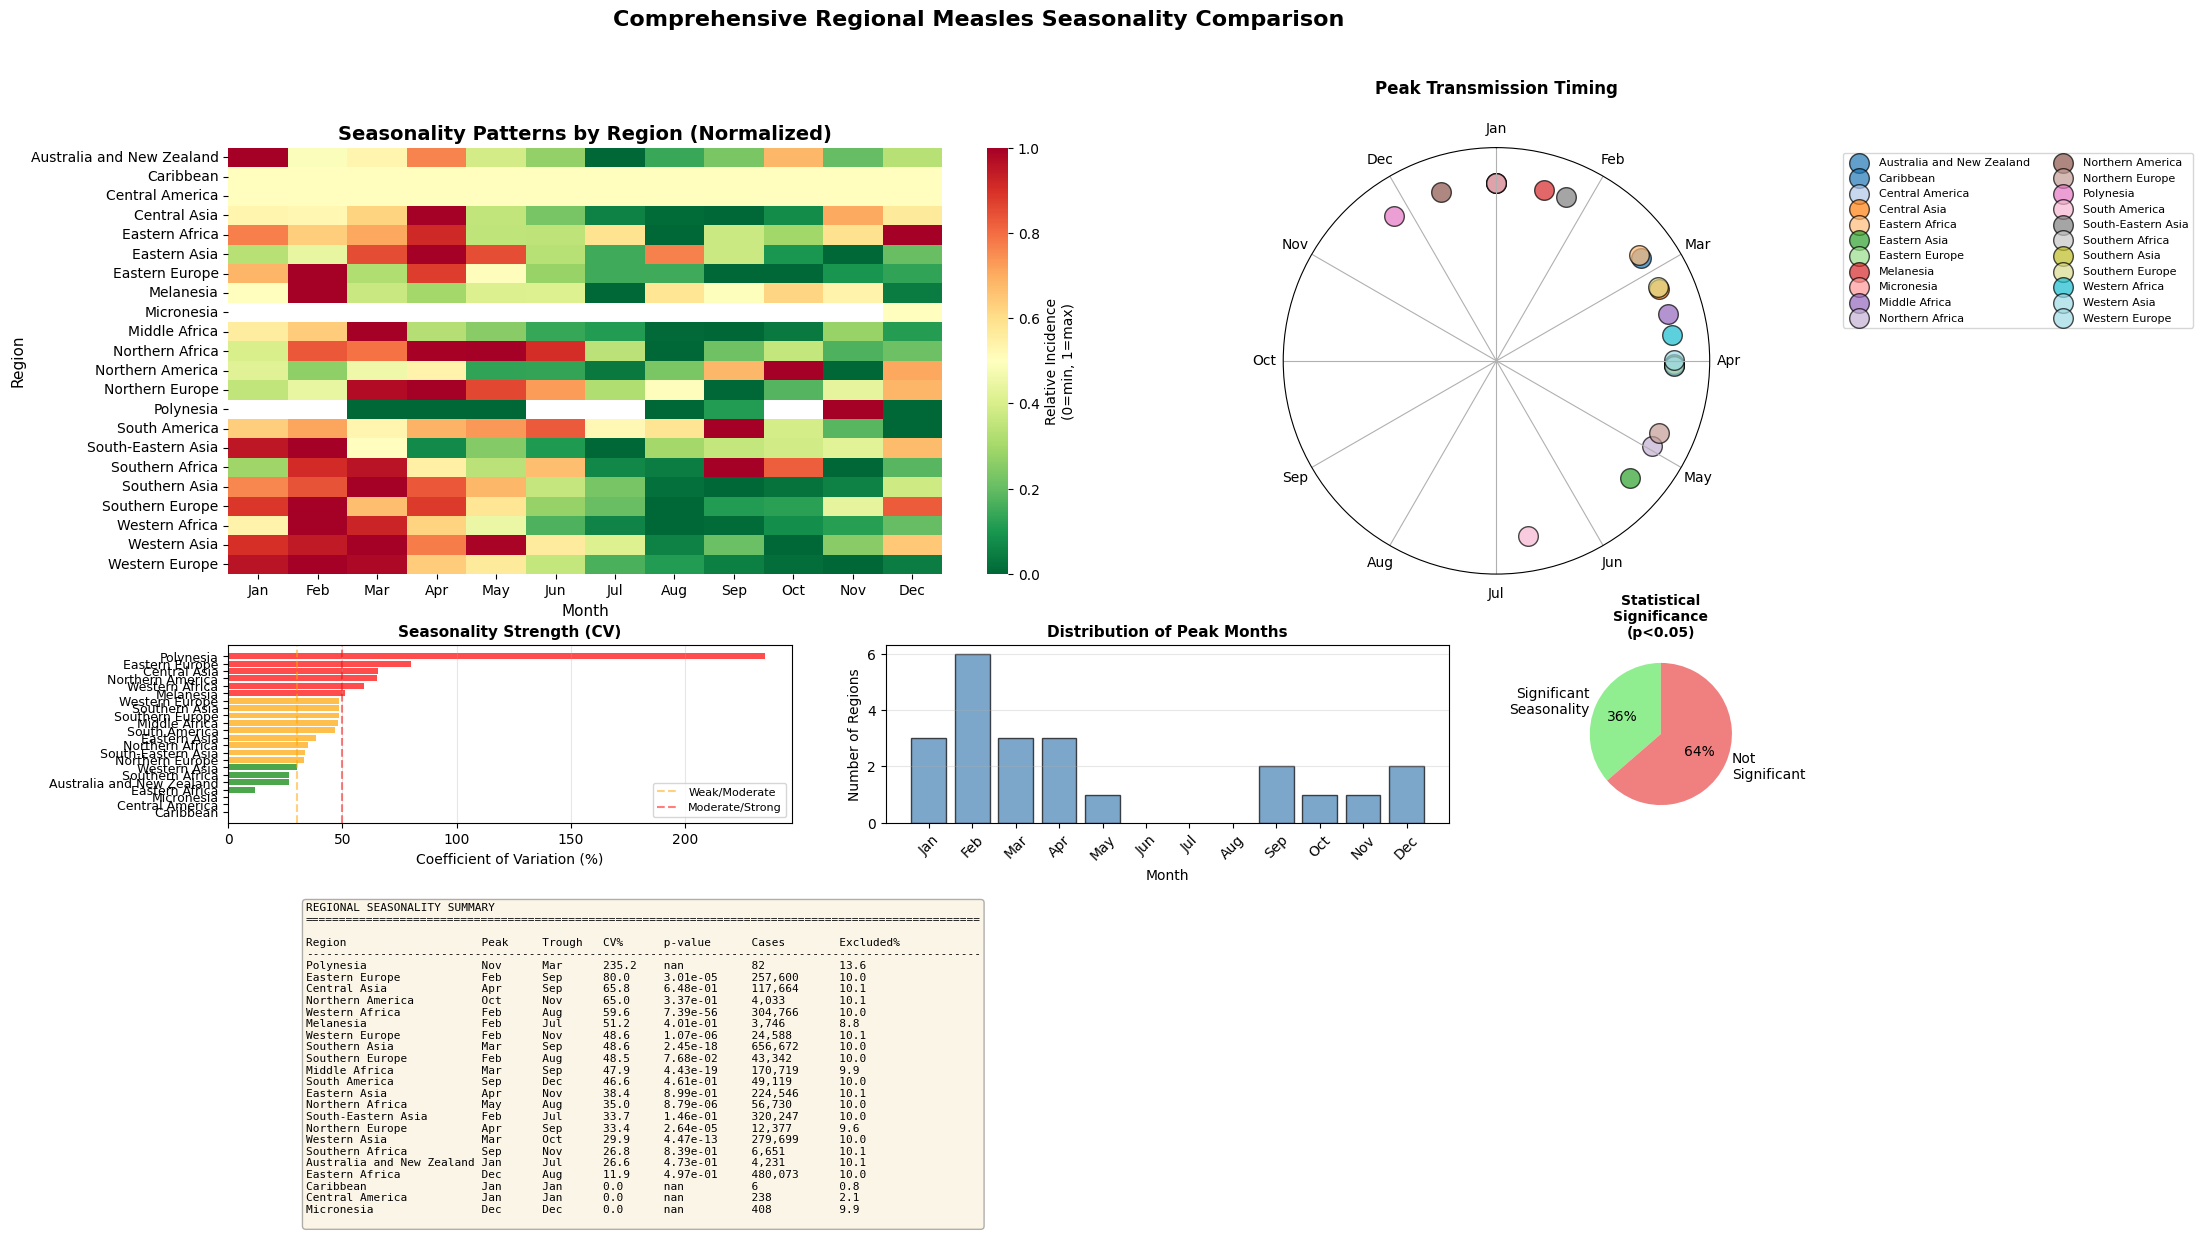

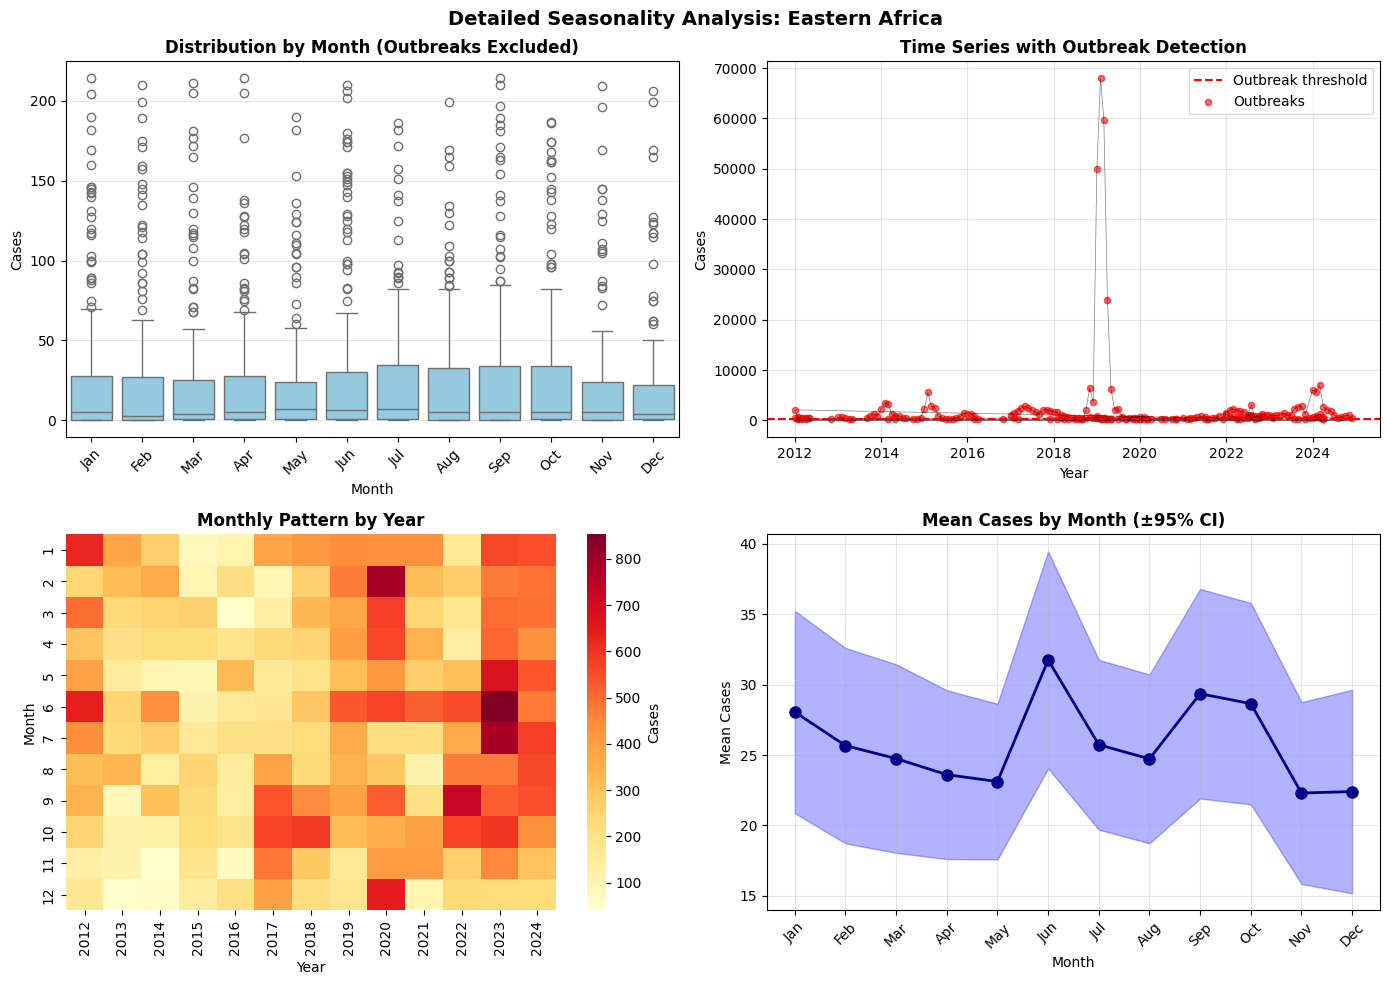

In [28]:
# Analyze all regions
results = analyze_regional_seasonality(
    who_international_casedata, 
    countries_harmfile,
    exclude_outbreaks=True,
    outbreak_threshold_method='percentile'  # or 'iqr' or 'zscore'
)



# Optionally: look at individual regions in detail
# for region in results['region'].head(5):  # Top 5 regions
#     plot_individual_region(who_international_casedata, countries_harmfile, region)
# ============ USAGE EXAMPLE ============

# Main analysis
results = analyze_regional_seasonality(
    who_international_casedata, 
    countries_harmfile,
    exclude_outbreaks=True,
    outbreak_threshold_method='percentile'  # try 'iqr' or 'zscore' too
)

# Comparison plot
plot_regional_comparison(results)

# Deep dive on interesting regions
plot_individual_region(who_international_casedata, countries_harmfile, 'Eastern Africa')

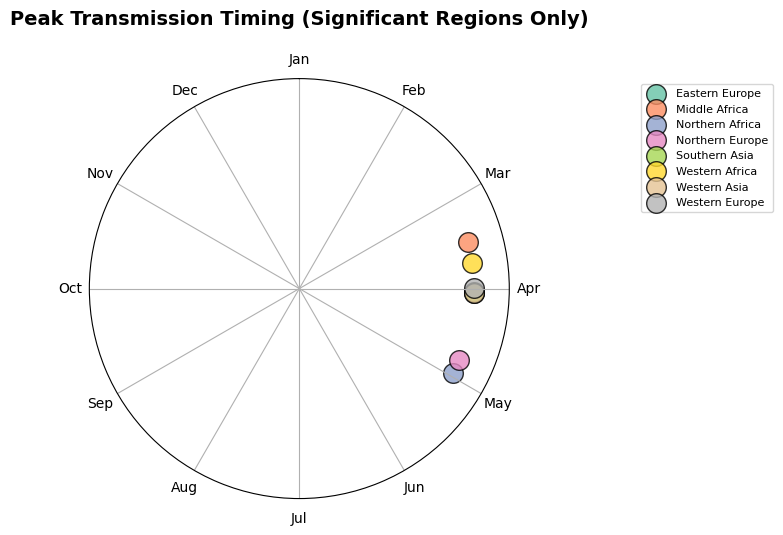

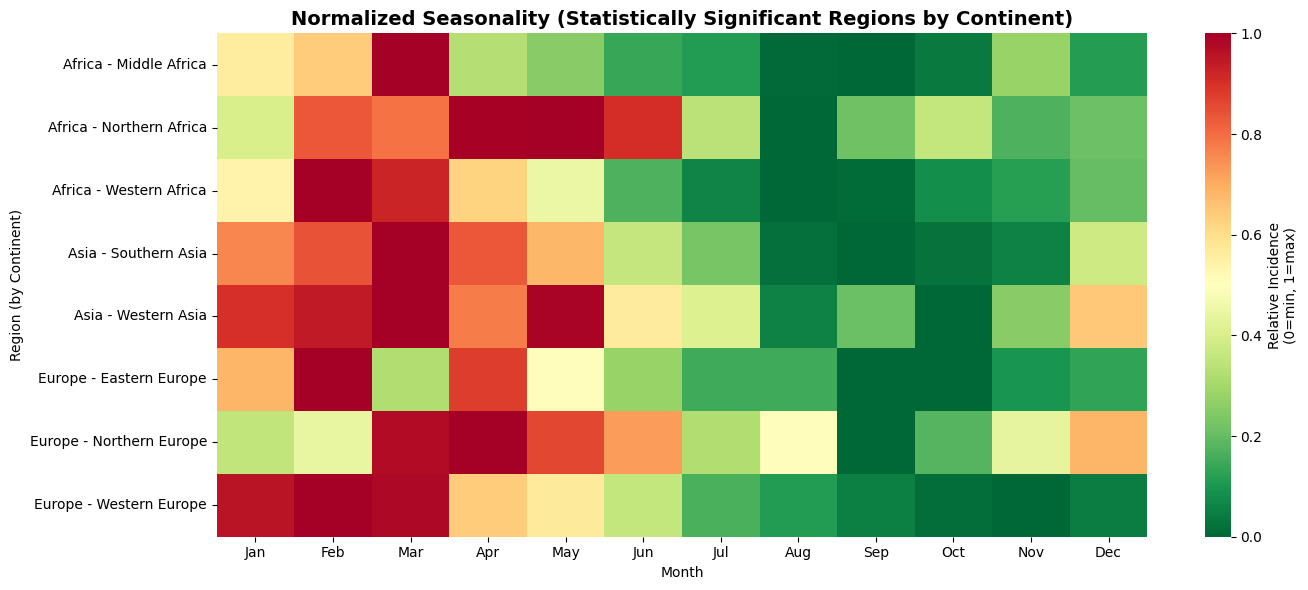

In [33]:
# Filter only statistically significant regions
significant_results = results[results['kw_pvalue'] < 0.05].copy()

# Add 'continent' info by mapping from countries_harmfile
region_to_continent = (
    countries_harmfile
    .drop_duplicates(subset=['region'])
    .set_index('region')['continent']
    .to_dict()
)

significant_results['continent'] = significant_results['region'].map(region_to_continent)
def plot_significant_circular(significant_results):
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

    theta = significant_results['mean_peak_month'].values * (2 * np.pi / 12)
    colors = plt.cm.Set2(np.linspace(0, 1, len(significant_results)))

    for i, (t, row) in enumerate(zip(theta, significant_results.itertuples())):
        ax.scatter(t, 1, s=200, alpha=0.8, color=colors[i],
                   label=row.region, edgecolors='black', linewidth=1)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
    ax.set_xticklabels(month_names)
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])

    ax.set_title('Peak Transmission Timing (Significant Regions Only)', fontsize=14, fontweight='bold', pad=20)
    ax.legend(bbox_to_anchor=(1.3, 1), loc='upper left', fontsize=8, ncol=1)

    plt.tight_layout()
    plt.show()
def plot_significant_heatmap_by_continent(significant_results):
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Prepare heatmap data
    heatmap_data = []
    labels = []

    # Sort by continent then region name
    sorted_df = significant_results.sort_values(['continent', 'region'])

    for idx, row in sorted_df.iterrows():
        monthly = row['monthly_pattern']
        values = np.full(12, np.nan)
        for i, month_val in enumerate(monthly['month'].values):
            values[int(month_val) - 1] = monthly['mean_norm'].values[i]

        # Normalize values to [0, 1] for each region
        valid = ~np.isnan(values)
        if valid.any():
            min_val = np.nanmin(values)
            max_val = np.nanmax(values)
            if max_val > min_val:
                values_scaled = (values - min_val) / (max_val - min_val)
            else:
                values_scaled = np.zeros_like(values)
        else:
            values_scaled = values

        heatmap_data.append(values_scaled)
        labels.append(f"{row['continent']} - {row['region']}")

    heatmap_array = np.array(heatmap_data)

    # Plot
    plt.figure(figsize=(14, max(6, len(labels) * 0.35)))
    sns.heatmap(heatmap_array, xticklabels=month_names, yticklabels=labels,
                cmap='RdYlGn_r', cbar_kws={'label': 'Relative Incidence\n(0=min, 1=max)'})
    plt.title('Normalized Seasonality (Statistically Significant Regions by Continent)', fontsize=14, fontweight='bold')
    plt.xlabel('Month')
    plt.ylabel('Region (by Continent)')
    plt.tight_layout()
    plt.show()
def plot_significant_summary(results_df, countries_harmfile):
    # Filter and add continent
    sig = results_df[results_df['kw_pvalue'] < 0.05].copy()
    region_to_continent = countries_harmfile.drop_duplicates('region').set_index('region')['continent'].to_dict()
    sig['continent'] = sig['region'].map(region_to_continent)

    plot_significant_circular(sig)
    plot_significant_heatmap_by_continent(sig)


plot_significant_summary(significant_results, countries_harmfile=countries_harmfile)

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage
from sklearn.preprocessing import StandardScaler

def creative_seasonality_analysis(results, countries_harmfile):
    # Merge on region and get continent
    df = results.merge(countries_harmfile[['region', 'continent']], on='region', how='left')

    # Validate monthly patterns
    def is_valid_pattern(p):
        return isinstance(p, (list, np.ndarray)) and len(p) == 12 and not any(pd.isna(p))

    df['valid_pattern'] = df['monthly_pattern'].apply(is_valid_pattern)
    df_valid = df[df['valid_pattern']].copy()

    if df_valid.empty:
        print("❌ No valid monthly patterns found. Nothing to analyze.")
        return

    # Extract pattern matrix
    pattern_matrix = np.vstack(df_valid['monthly_pattern'].values)

    # Normalize (unit norm)
    pattern_matrix = pattern_matrix / np.linalg.norm(pattern_matrix, axis=1, keepdims=True)

    # PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(pattern_matrix)
    df_valid['PC1'] = pcs[:, 0]
    df_valid['PC2'] = pcs[:, 1]

    # PCA scatter by continent
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_valid, x='PC1', y='PC2', hue='continent', style=df_valid['kw_pvalue'] < 0.05)
    plt.title('PCA of Seasonality Patterns (by continent)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Clustering heatmap
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(pattern_matrix)
    linkage_matrix = linkage(X_scaled, method='ward')

    sns.clustermap(
        X_scaled,
        row_linkage=linkage_matrix,
        col_cluster=False,
        figsize=(12, 10),
        cmap='coolwarm',
        yticklabels=df_valid['region'].values,
        xticklabels=[f'Month {i+1}' for i in range(12)]
    )
    plt.suptitle('Clustered Seasonality Patterns by Region', y=1.02)
    plt.show()

    # Peak month by continent
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_valid, x='continent', y='peak_month')
    sns.stripplot(data=df_valid, x='continent', y='peak_month', color='black', size=3, alpha=0.5)
    plt.title('Peak Month Distribution by Continent')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"✅ Analysis complete. Included {len(df_valid)} valid regions out of {len(df)} total.")

# Run it
creative_seasonality_analysis(results, countries_harmfile)


❌ No valid monthly patterns found. Nothing to analyze.


In [44]:
results

,region,peak_month,trough_month,mean_peak_month,cv,kw_pvalue,n_months,n_excluded,pct_excluded,total_cases,monthly_pattern
0,Australia and New Zealand,1,7,1.823397,26.558366,4.731620e-01,231,26,10.116732,4231.0,month mean_norm median_norm std_norm c...
1,Caribbean,1,1,12.000000,0.000000,NaN,645,5,0.769231,6.0,month mean_norm median_norm std_norm c...
2,Central America,1,1,12.000000,0.000000,NaN,835,18,2.110199,238.0,month mean_norm median_norm std_norm c...
3,Central Asia,4,9,2.205500,65.795542,6.482583e-01,577,65,10.124611,117664.0,month mean_norm median_norm std_norm ...
4,Eastern Africa,12,8,1.786286,11.886124,4.971010e-01,2089,233,10.034453,480073.0,month mean_norm median_norm std_norm c...
5,Eastern Asia,4,11,4.381330,38.351203,8.990338e-01,670,75,10.067114,224546.0,month mean_norm median_norm std_norm c...
6,Eastern Europe,2,9,3.045649,80.016159,3.010514e-05,1170,130,10.000000,257600.0,month mean_norm median_norm std_norm ...
7,Melanesia,2,7,12.515175,51.226145,4.014962e-01,289,28,8.832808,3746.0,month mean_norm median_norm std_norm c...
8,Micronesia,12,12,12.000000,0.000000,NaN,64,7,9.859155,408.0,month mean_norm median_norm std_norm co...
9,Middle Africa,3,9,2.485875,47.913870,4.429149e-19,1070,118,9.932660,170719.0,month mean_norm median_norm std_norm c...


In [40]:
print(results.columns)
print(countries_harmfile.columns)


Index(['region', 'peak_month', 'trough_month', 'mean_peak_month', 'cv',
       'kw_pvalue', 'n_months', 'n_excluded', 'pct_excluded', 'total_cases',
       'monthly_pattern'],
      dtype='object')
Index(['country', 'iso_code', 'continent', 'region'], dtype='object')


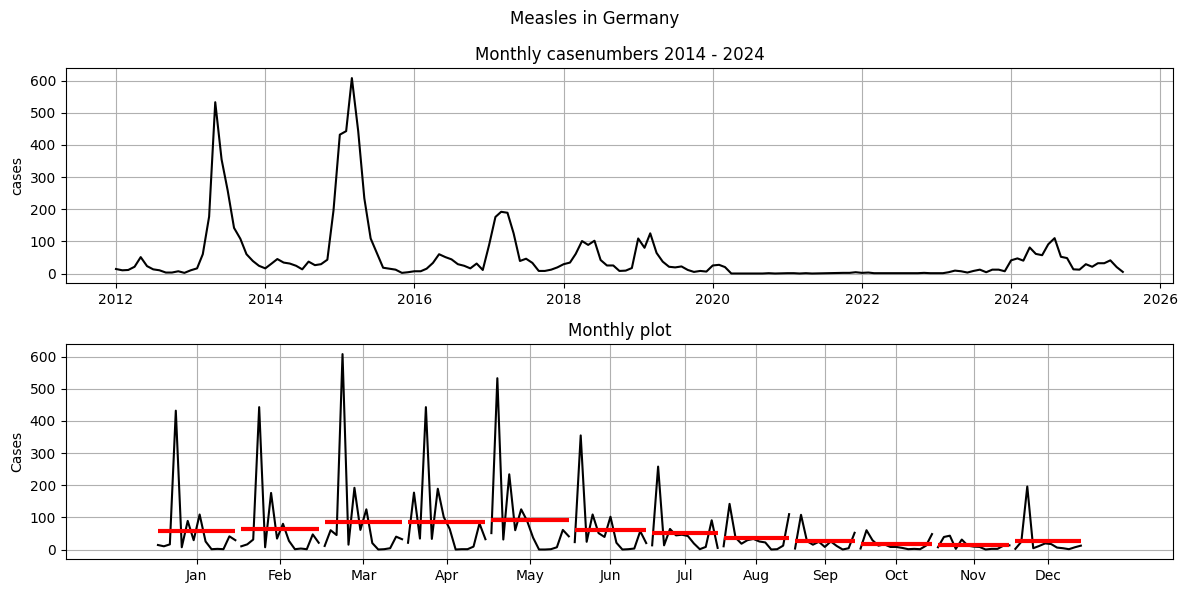

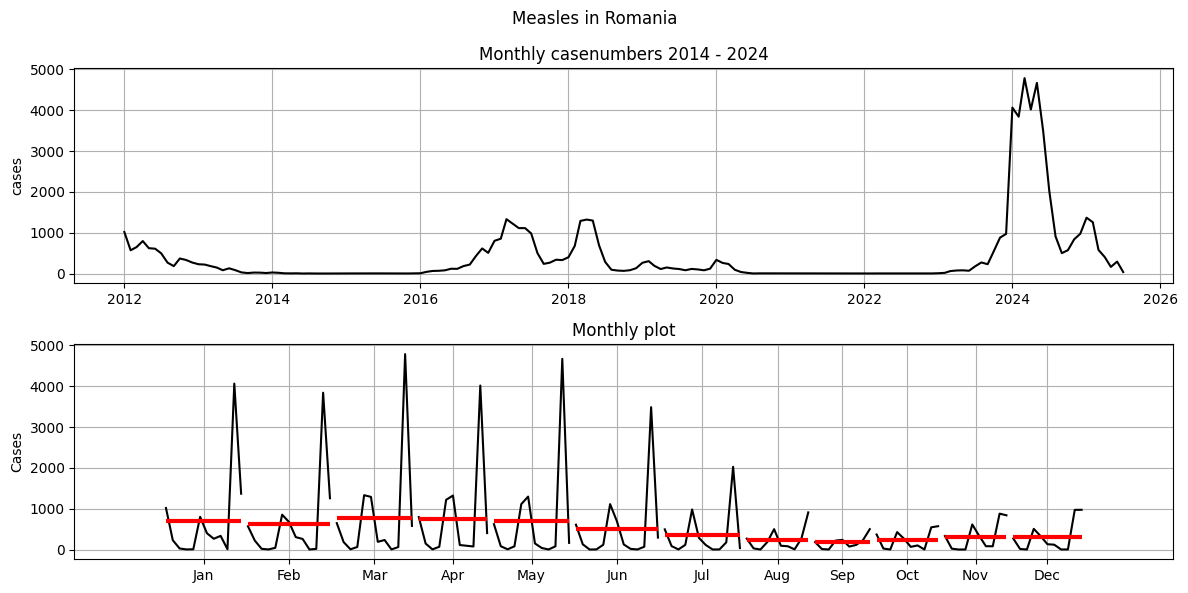

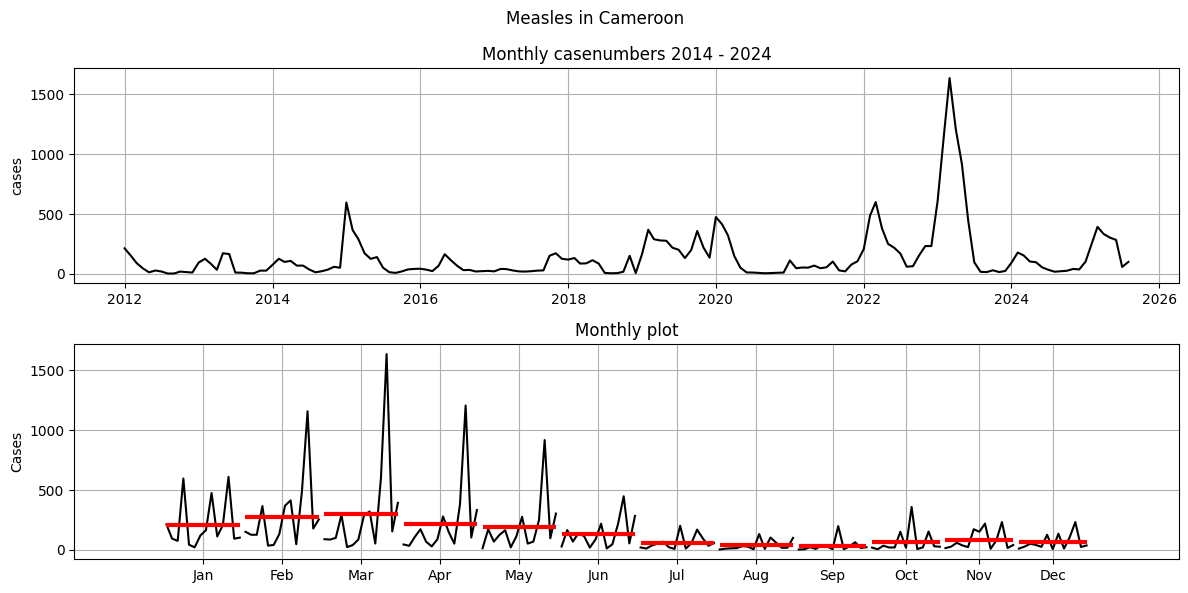

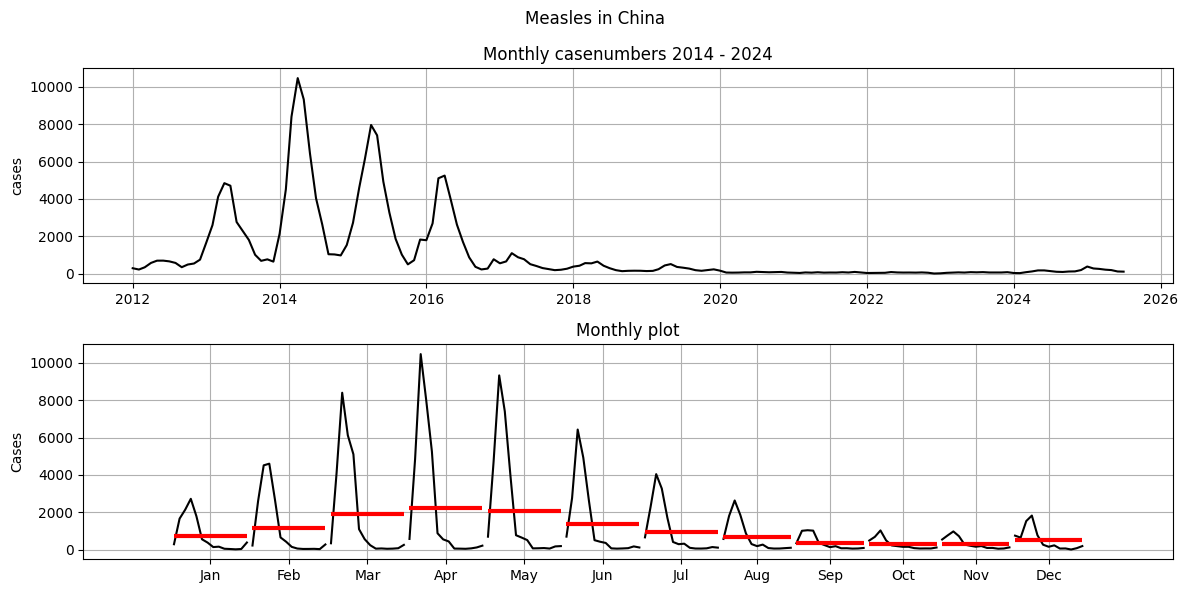

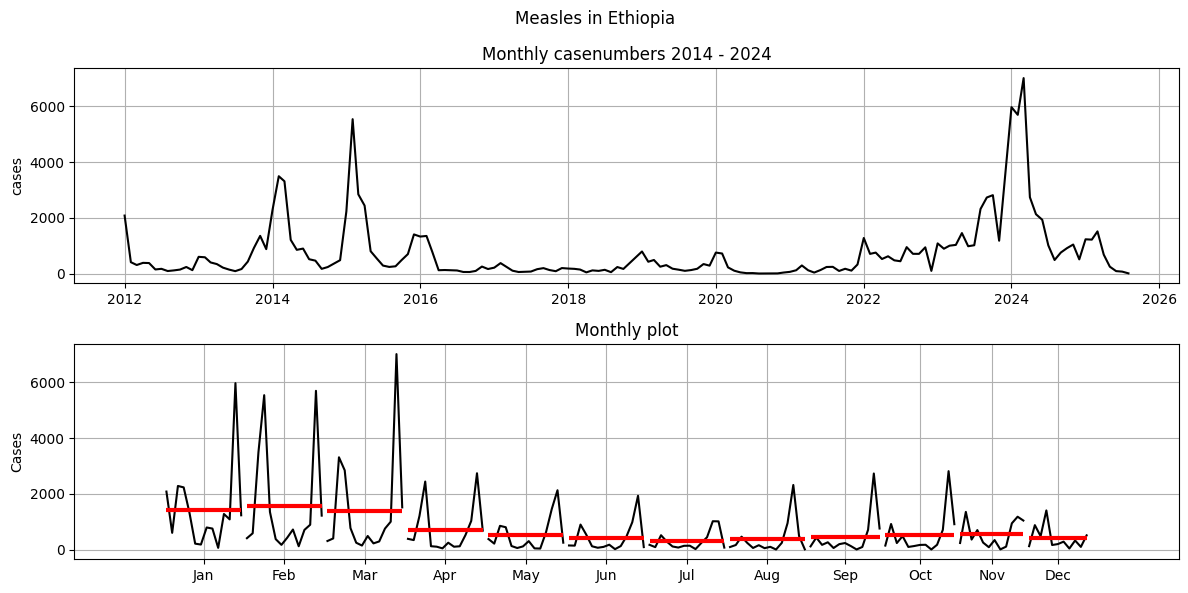

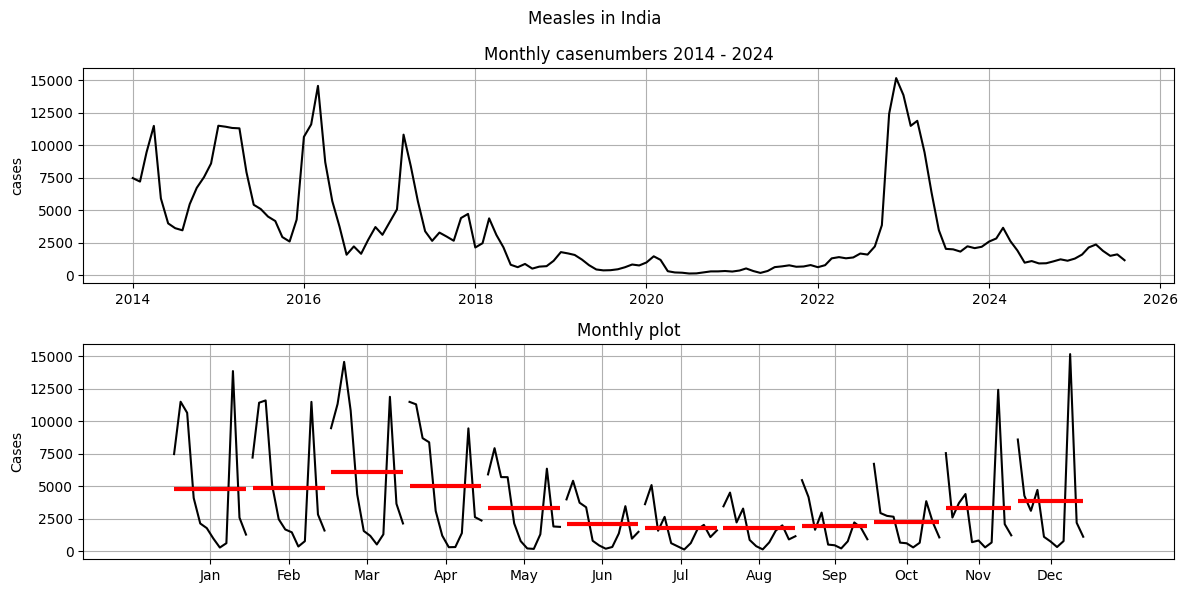

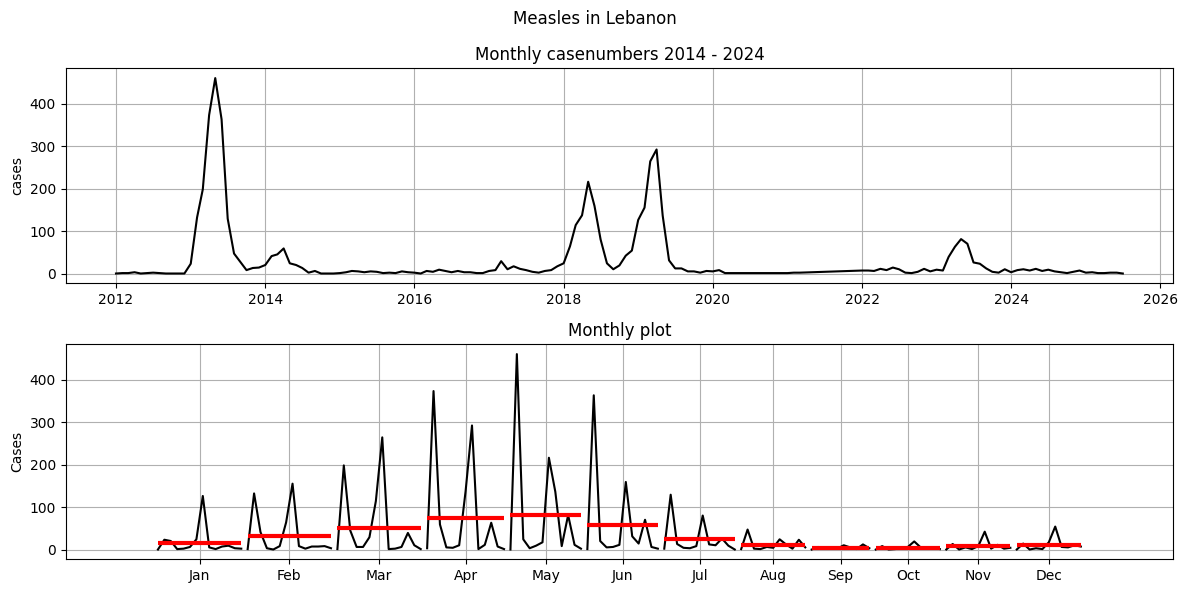

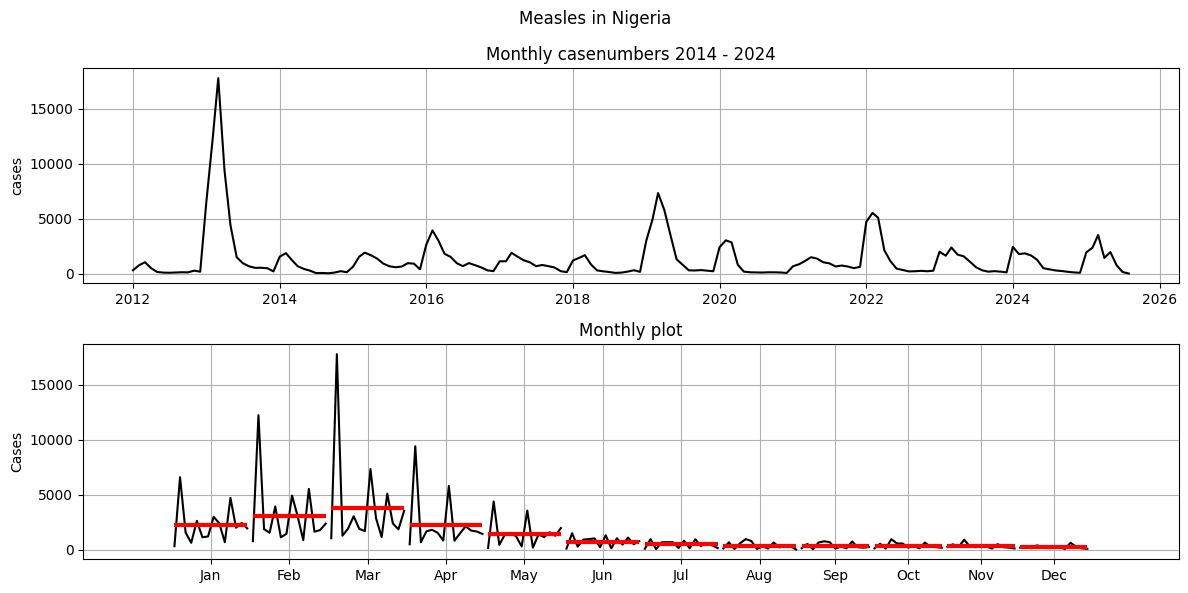

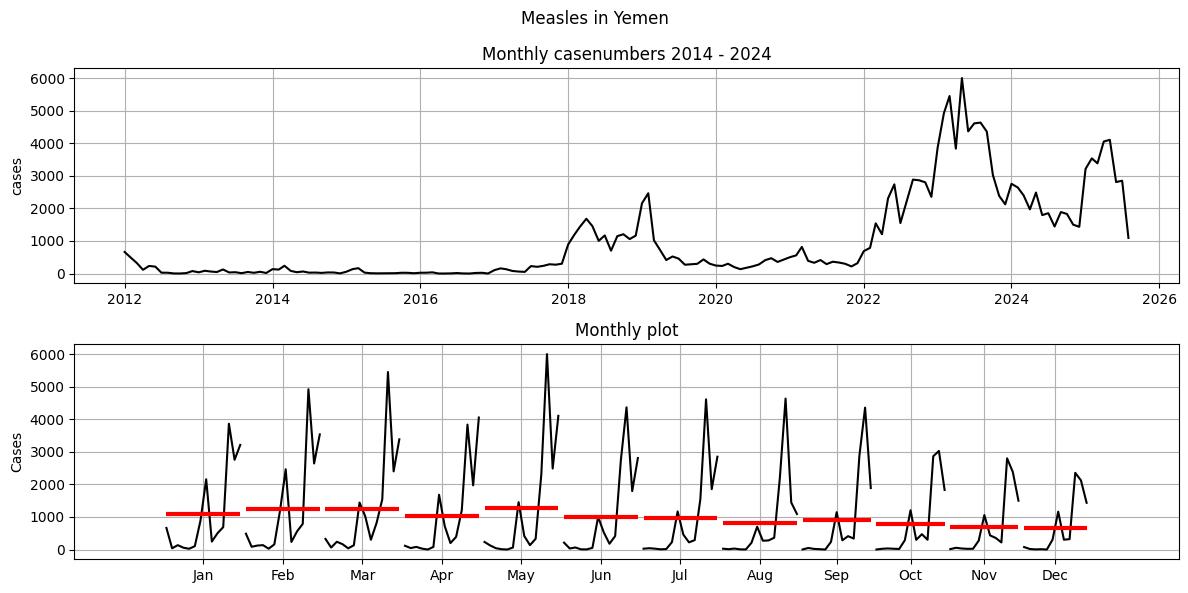

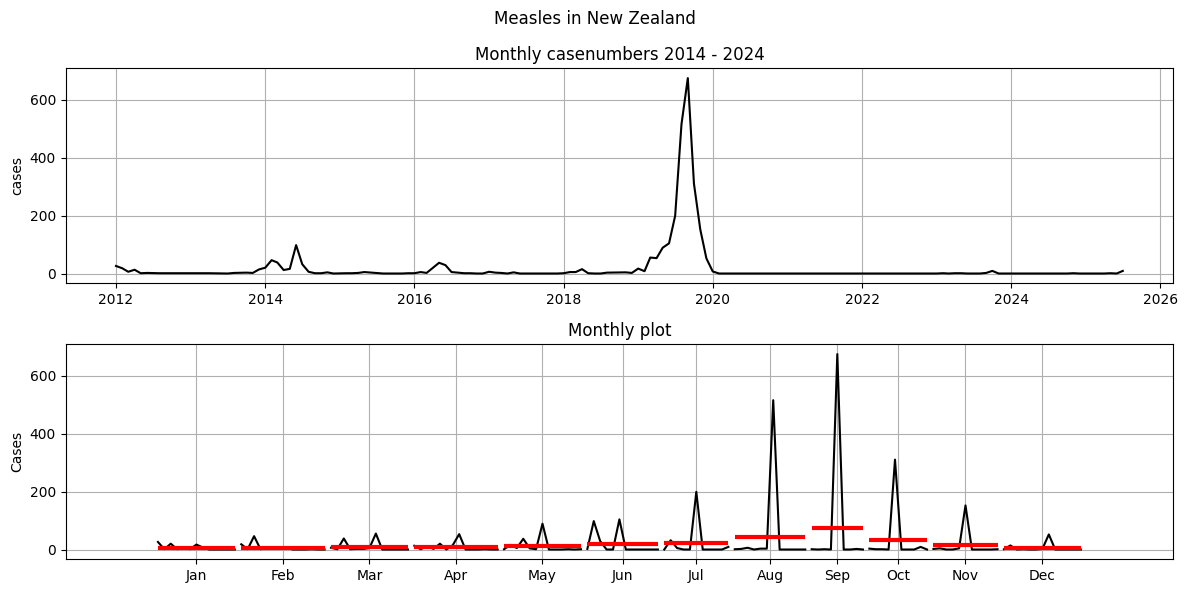

In [8]:
countries_of_interest = ['Germany','Romania','Cameroon','China','Ethiopia','India','Lebanon','Nigeria','Yemen','New Zealand']
for cc in countries_of_interest:
# for cc in who_international_casedata['country'].unique():
    try:
        plot_monthly_statsmodels(who_international_casedata, cc)
    except Exception as e:
        # Optionally, you can log or print the error:
        # print(f"Error processing {cc}: {e}")
        pass


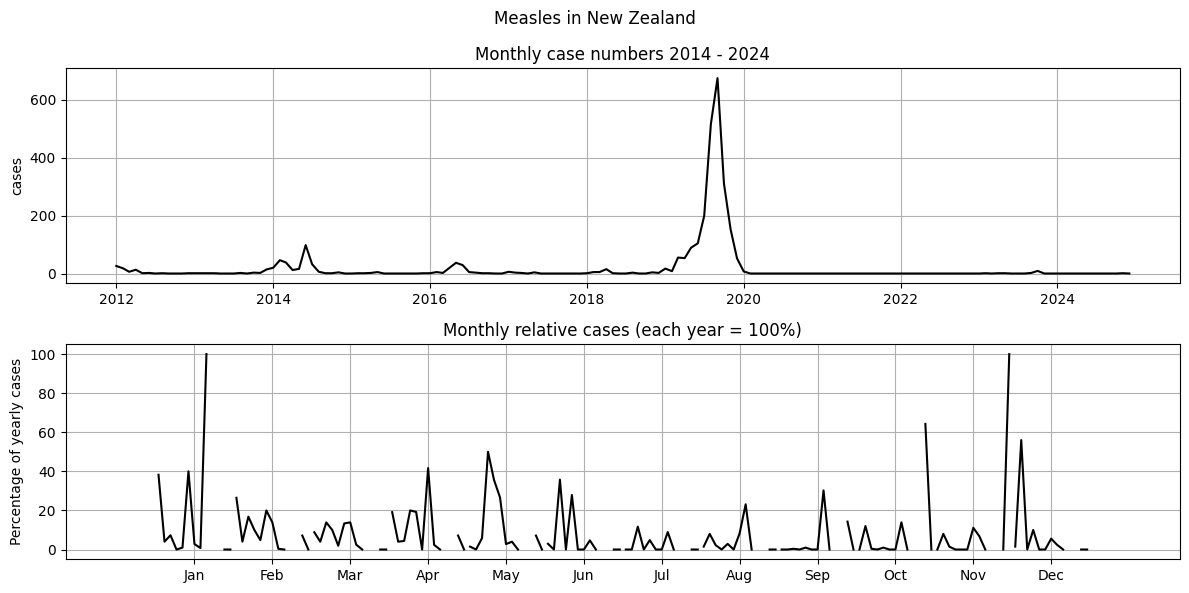

In [54]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot
import seaborn as sns
import pandas as pd

def plot_monthly_relative_statsmodels(df, country):
    df = df.copy()
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    axes = axes.flatten()

    df_c = df[df['country'] == country].copy()
    df_c['timestamp'] = pd.to_datetime(df_c['timestamp'])
    df_c = df_c.set_index('timestamp')
    df_c = df_c.sort_index()

    # Create full monthly period range (PeriodIndex) instead of DatetimeIndex
    full_range = pd.period_range(start=df_c.index.min(), end=df_c.index.max(), freq='M')

    # Convert df_c.index to PeriodIndex to match full_range
    df_c.index = df_c.index.to_period('M')

    # Reindex with full_range to fill missing months
    df_c = df_c.reindex(full_range)

    # Fill missing 'country' column after reindexing
    df_c['country'] = country

    # Fill missing 'cases' with 0
    df_c['cases'] = df_c['cases'].fillna(0)

    # Plot absolute cases
    sns.lineplot(data=df_c, x=df_c.index.to_timestamp(), y='cases', ax=axes[0], color='black')
    axes[0].grid(True)
    axes[0].set_title('Monthly case numbers 2014 - 2024')
    axes[0].set_xlabel('')

    # Add year column for normalization
    df_c['year'] = df_c.index.year

    # Normalize monthly cases by yearly total
    yearly_sums = df_c.groupby('year')['cases'].transform('sum')
    df_c['cases_relative'] = df_c['cases'] / yearly_sums * 100  # percentage

    ts_rel = df_c['cases_relative']

    month_plot(ts_rel, ax=axes[1])
    axes[1].grid(True)
    axes[1].set_title('Monthly relative cases (each year = 100%)')
    axes[1].set_ylabel('Percentage of yearly cases')

    plt.suptitle(f'Measles in {country}')
    fig.tight_layout()
    plt.show()



plot_monthly_relative_statsmodels(who_international_casedata, 'New Zealand')